# **Project Title : Salary Prediction of Software Developers**
## Group Number : 08
Student Names & Registration Numbers:

       EG/2020/4197 - Senanayake H.A.S.I.B.

       EG/2020/4299 - Wijesinghe P.G.M.P.H.

# Introduction

Predicting salaries in the technology industry has become an increasingly important task for organizations, policy makers, and professionals. With rapid growth in software development and the global demand for skilled developers, salaries vary significantly across countries, job roles, levels of education, and years of professional experience. Understanding these variations can help companies design competitive compensation packages while enabling developers to make informed career decisions.

This project focuses on predicting developer salaries using the Stack Overflow Developer Survey 2024 dataset, which is one of the most comprehensive datasets available on global software professionals. The dataset captures key demographic and professional attributes of developers, including education level, country, years of coding experience, preferred technologies, and job satisfaction, along with self-reported compensation.

By applying machine learning techniques, we aim to uncover patterns in the data that influence developer salaries. The project involves several stages: data exploration, preprocessing, model training, and evaluation. Multiple models are tested and compared to identify which provides the most accurate predictions.

The outcomes of this work not only provide insights into the key factors affecting developer salaries but also demonstrate the potential of predictive modeling in real-world human resource and labor market analysis.

# Literature Survey

Several research studies and industrial analyses have focused on predicting salaries using statistical and machine learning techniques. These works highlight how demographic, educational, and professional factors contribute to income variation in the technology sector.

**Traditional Statistical Approaches**

Early studies on salary prediction often employed regression-based techniques such as Ordinary Least Squares (OLS) regression to model the linear relationship between demographic attributes and compensation. While useful for identifying basic correlations (e.g., education vs. salary), these approaches struggled with handling nonlinear interactions and categorical variables[1].

**Machine Learning Models**

Recent research has applied supervised learning algorithms such as Decision Trees, Random Forests, Gradient Boosting (XGBoost, LightGBM), and Support Vector Machines. For example, some works demonstrated that ensemble methods outperform simple linear models by capturing complex relationships in survey data, especially when categorical features like country or role are included.

**Neural Networks in Salary Prediction**

A few studies have explored deep learning techniques, particularly feed-forward neural networks, to predict salaries based on multi-dimensional inputs (e.g., skills, years of experience, education). Although neural networks can achieve higher predictive accuracy, they often require larger datasets and careful preprocessing[2].

**Human Resource Analytics**

Beyond academic research, industry reports highlight the importance of labor market analytics using survey data such as Stack Overflow’s annual developer survey[3]. These studies provide actionable insights into global salary trends, helping organizations benchmark compensation strategies.

**Stack Overflow Developer Survey in Research**

The Stack Overflow dataset is widely used in salary prediction studies due to its richness and global scope. Prior works have shown that features such as country of employment, years of professional coding experience, and education level are among the strongest predictors of salary. However, challenges such as missing values, self-reported bias, and uneven geographical distribution remain.

In summary, the literature indicates that machine learning models, particularly ensemble methods, provide robust performance in salary prediction tasks[4]. This project builds on these findings by leveraging the 2024 Stack Overflow Developer Survey to design and evaluate predictive models for developer compensation.


# Dataset Description

The dataset used in this project is the Stack Overflow Developer Survey 2024, an extensive annual survey that collects responses from professional and aspiring software developers across the globe. It contains demographic, educational, and professional details along with information about tools, platforms, and technologies developers use.

For the salary prediction task, a subset of the dataset is utilized. Specifically, nine features are selected as predictors of salary, while the ConvertedCompYearly field is used as the target variable (representing annual compensation in USD).

## Selected Features

       -RemoteWork – Whether the developer works fully remote, hybrid, or onsite.
       -EdLevel – Highest level of formal education attained (e.g., Bachelor’s, Master’s, PhD).
       -YearsCodePro – Number of years of professional coding experience.
       -DevType – Primary role(s) of the developer (e.g., Backend Developer, Data Scientist).
       -LanguageHaveWorkedWith – Programming languages the developer has experience with.
       -PlatformHaveWorkedWith – Platforms used by the developer (e.g., AWS, Windows, Linux).
       -ToolsTechHaveWorkedWith – Tools and technologies used (e.g., Git, Docker, Kubernetes).
       -Country – Country of employment.
       -Age – Age of the respondent.
       -Target Variable (ConvertedCompYearly (Salary)) – The self-reported annual compensation of the developer, converted into US Dollars for consistency across countries.

## Dataset Characteristics

Number of rows: ~70,000 responses (before cleaning; varies after preprocessing).

Number of columns (raw dataset): Over 80 survey fields.

Data type mix: Categorical (e.g., Country, EdLevel), multi-label categorical (e.g., languages, tools), and numerical (e.g., Age, YearsCodePro, Salary).

This dataset provides a diverse set of predictors, making it suitable for building machine learning models that can capture the complex relationships influencing developer salaries.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step to understand the dataset’s structure, detect missing values, examine distributions, and identify potential relationships between features and salary. This process guides the data preprocessing and feature engineering stages of the project.


In [1]:
import numpy as np
import pandas as pd
from dataset.load import load_df, select_feature
from dataset.preprocess import *
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def change_UK(val):
    if val == "United Kingdom of Great Britain and Northern Ireland":
        return "UK"

In [3]:
df = select_feature()
print(f"Dataframe shape: {df.shape}")
df.head(3)

df = df["Country"].apply(change_UK)

Dataframe shape: (14287, 10)


1. AGE

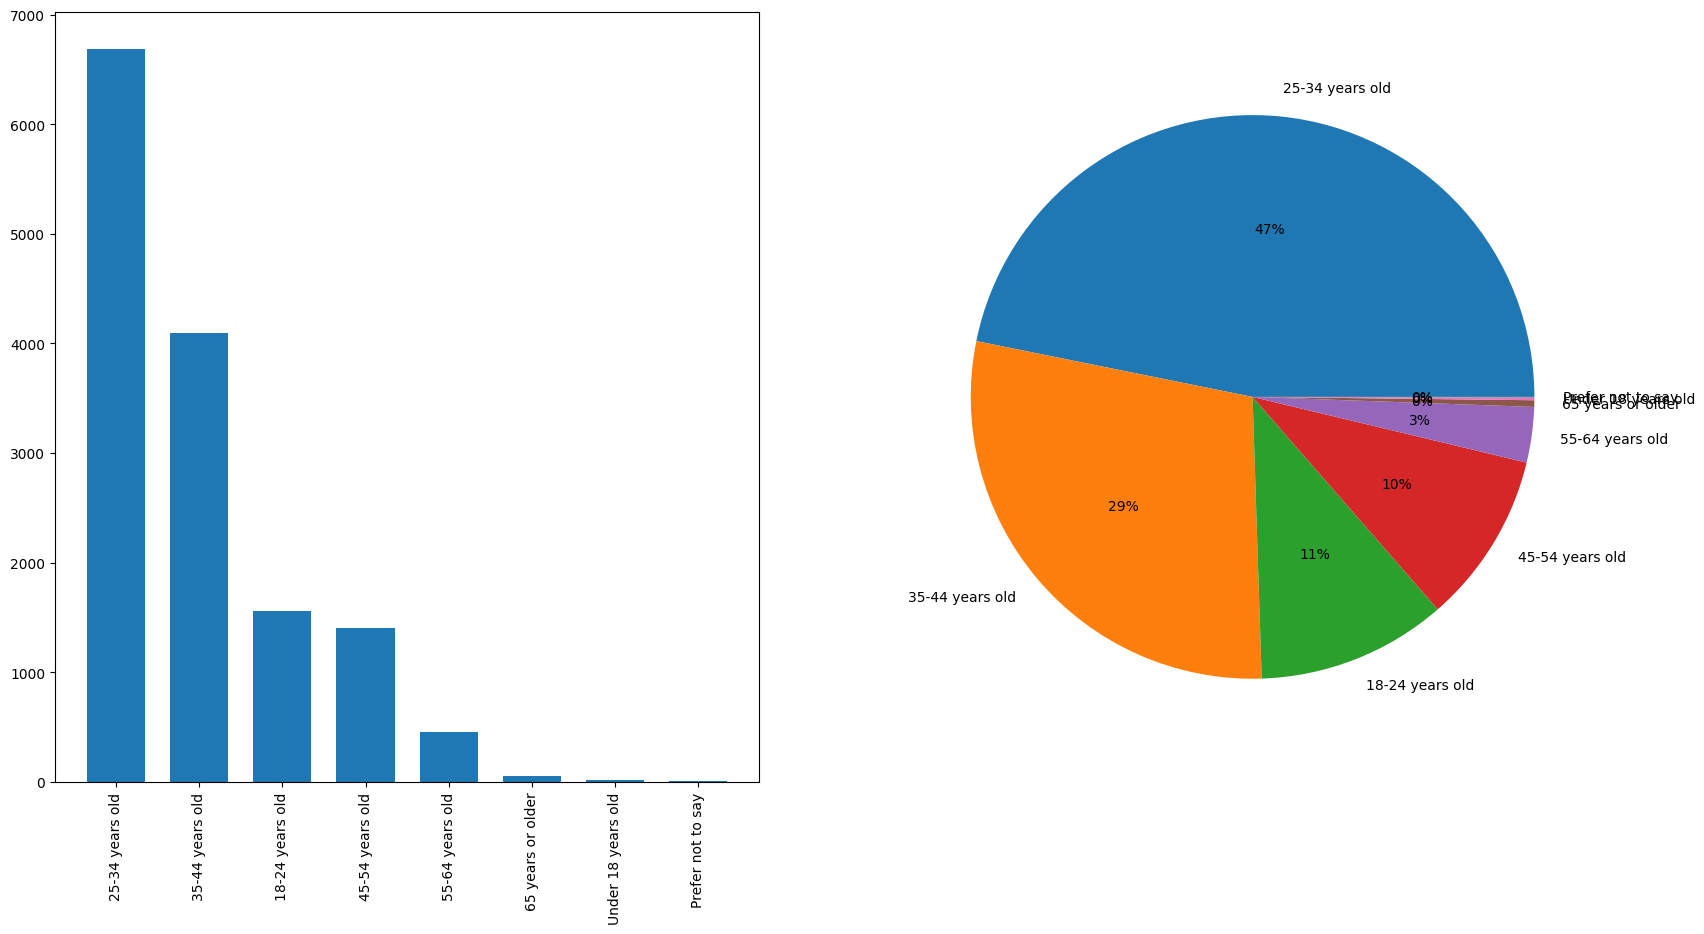

In [4]:
# Re-load the full dataframe to access the 'Age' column
full_df = select_feature()

age = full_df["Age"].value_counts()

label = age.index
value = age.values

plt.figure(figsize=(20, 10))
plt.subplot(1,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

plt.show()

2. REMOTE WORK

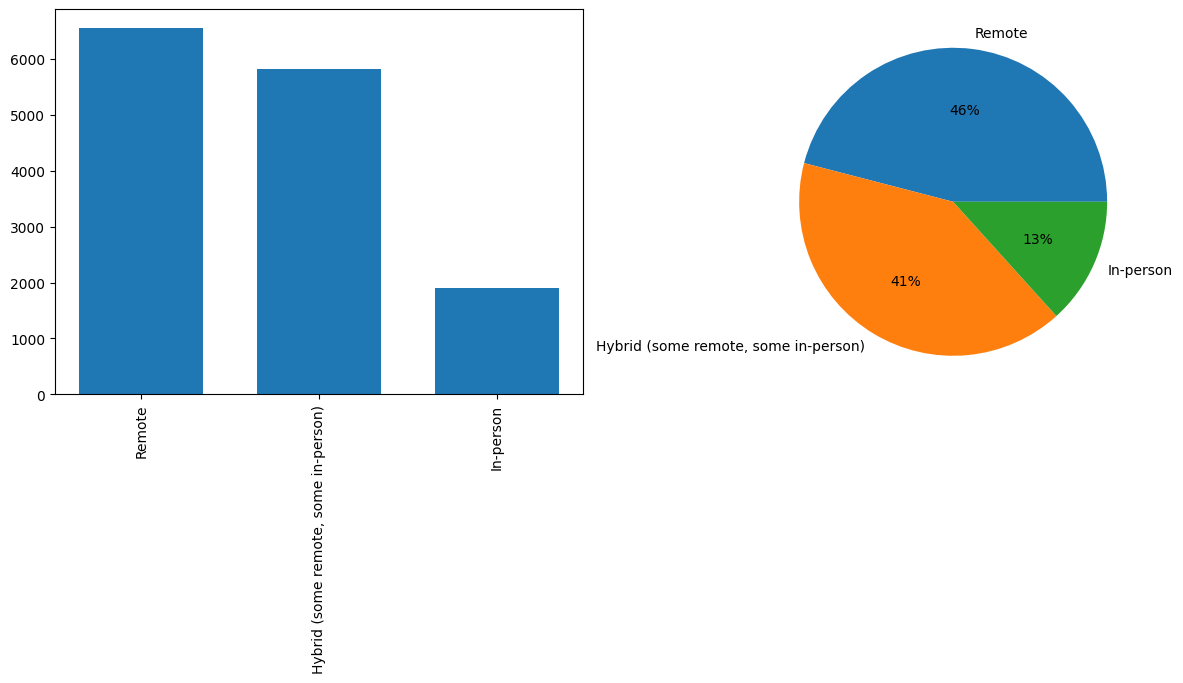

In [5]:
remote = full_df["RemoteWork"].value_counts()

label = remote.index
value = remote.values

plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

plt.show()

3. EDLevel

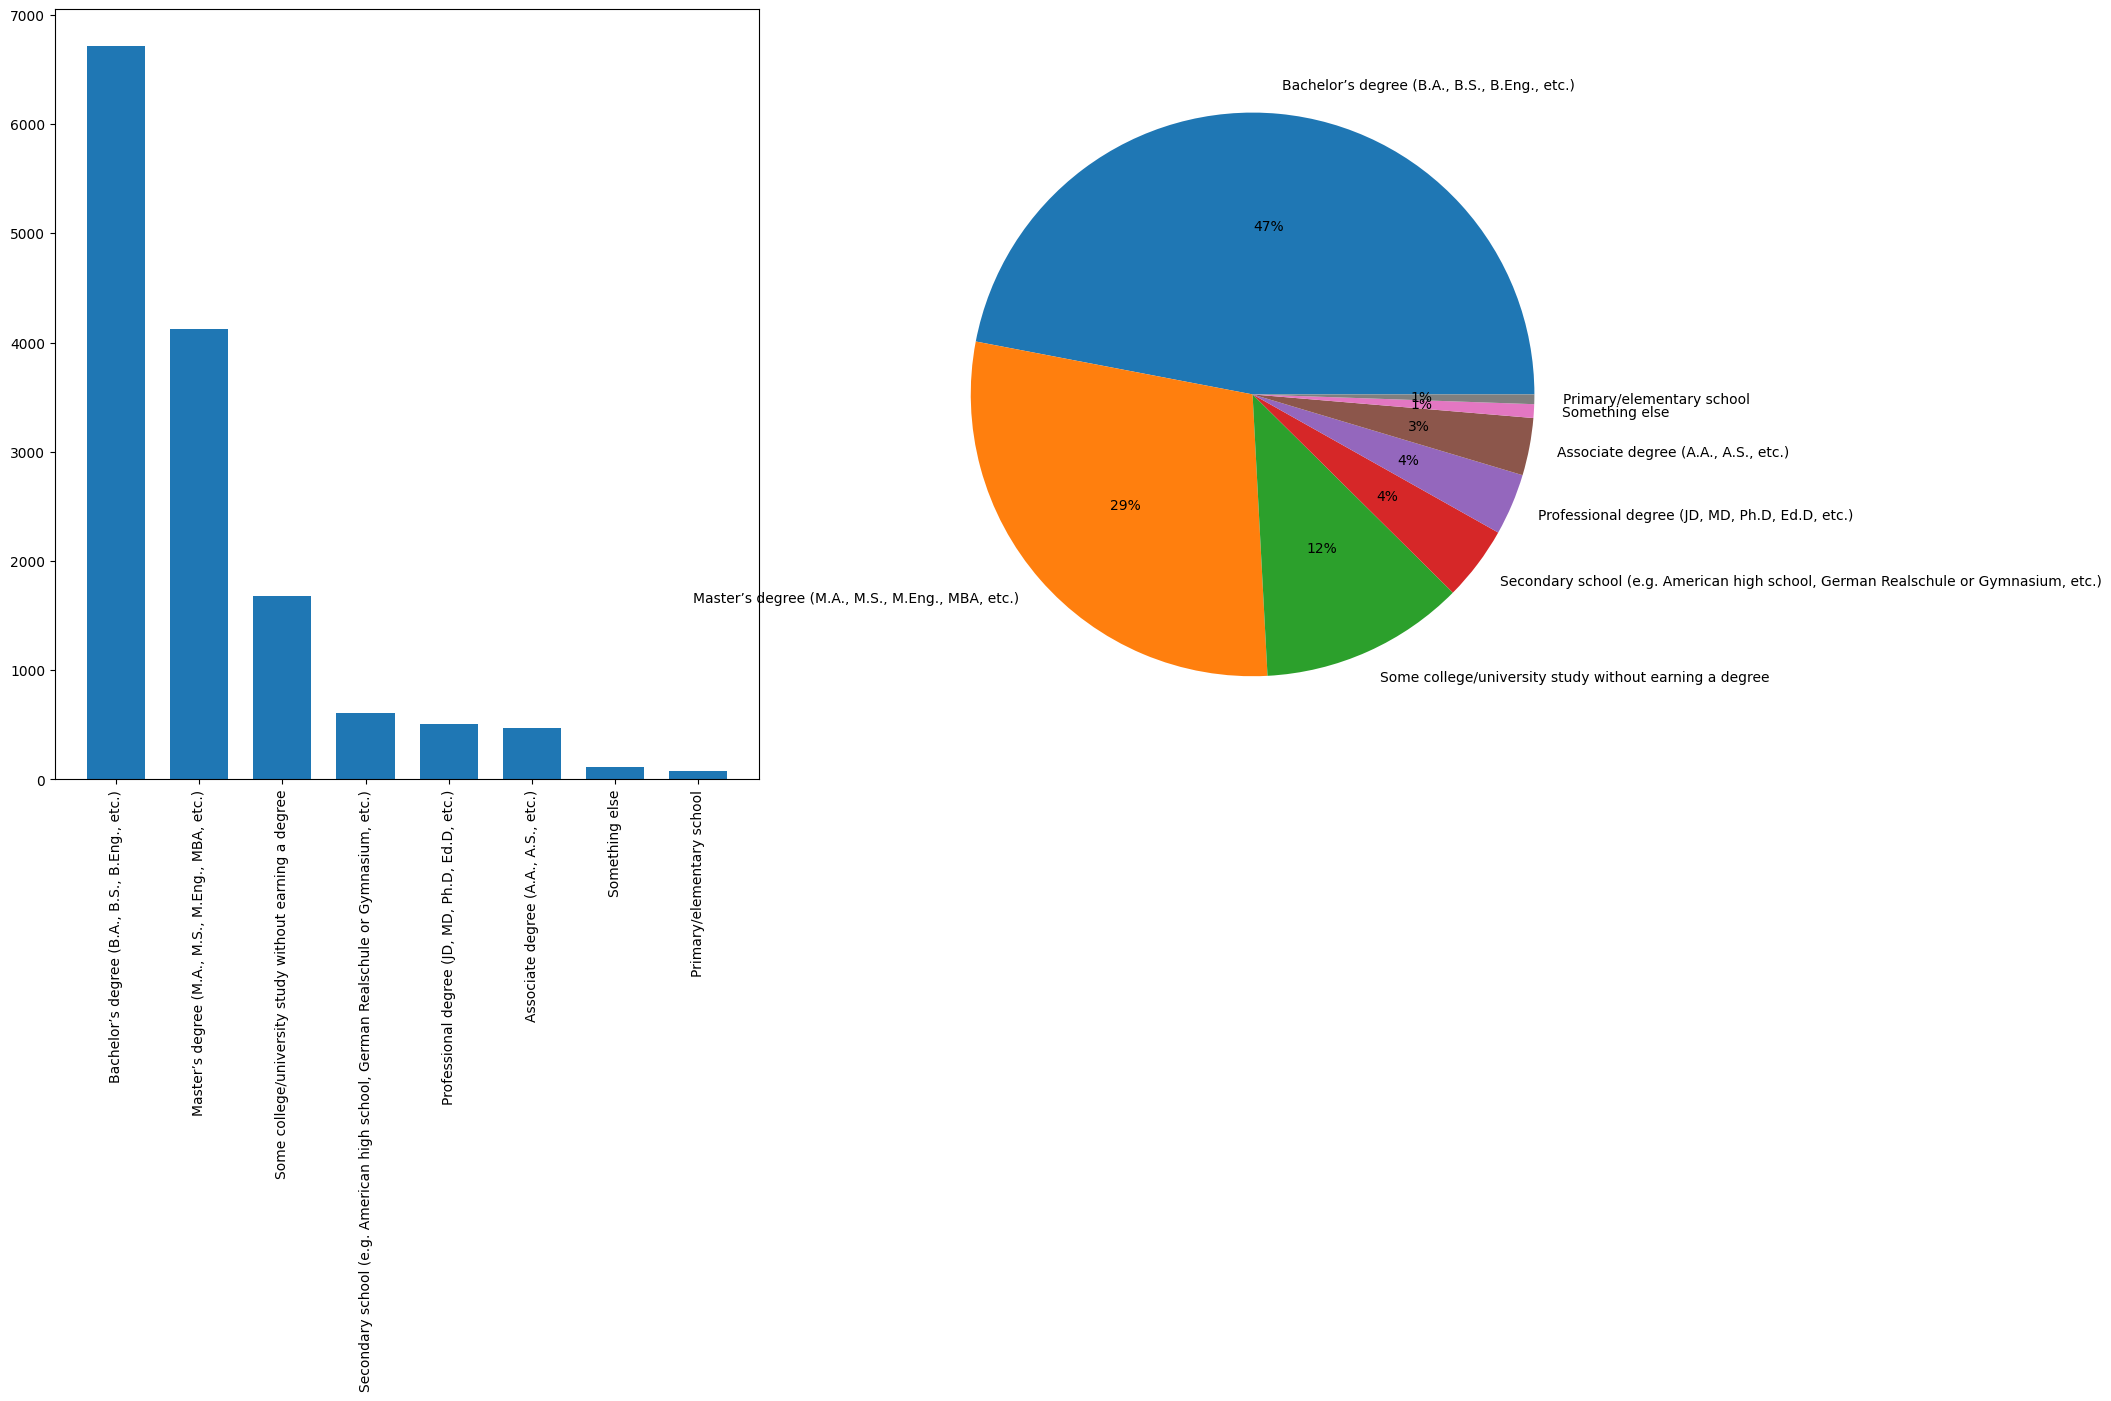

In [6]:
ed = full_df["EdLevel"].value_counts()

label = ed.index
value = ed.values

plt.figure(figsize=(20, 10))
plt.subplot(1,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

plt.show()

full_df["EdLevel"] = full_df["EdLevel"].apply(clean_education)

4. Country

In [7]:
country_map = shorten_categories(full_df["Country"].value_counts(), 200)
full_df["Country"] = full_df["Country"].map(country_map)
full_df["Country"].value_counts()

Country
Other                                                   4319
United States of America                                3015
Germany                                                  964
United Kingdom of Great Britain and Northern Ireland     917
Ukraine                                                  914
India                                                    682
Canada                                                   572
France                                                   499
Brazil                                                   431
Poland                                                   351
Spain                                                    350
Netherlands                                              344
Australia                                                333
Italy                                                    307
Sweden                                                   289
Name: count, dtype: int64

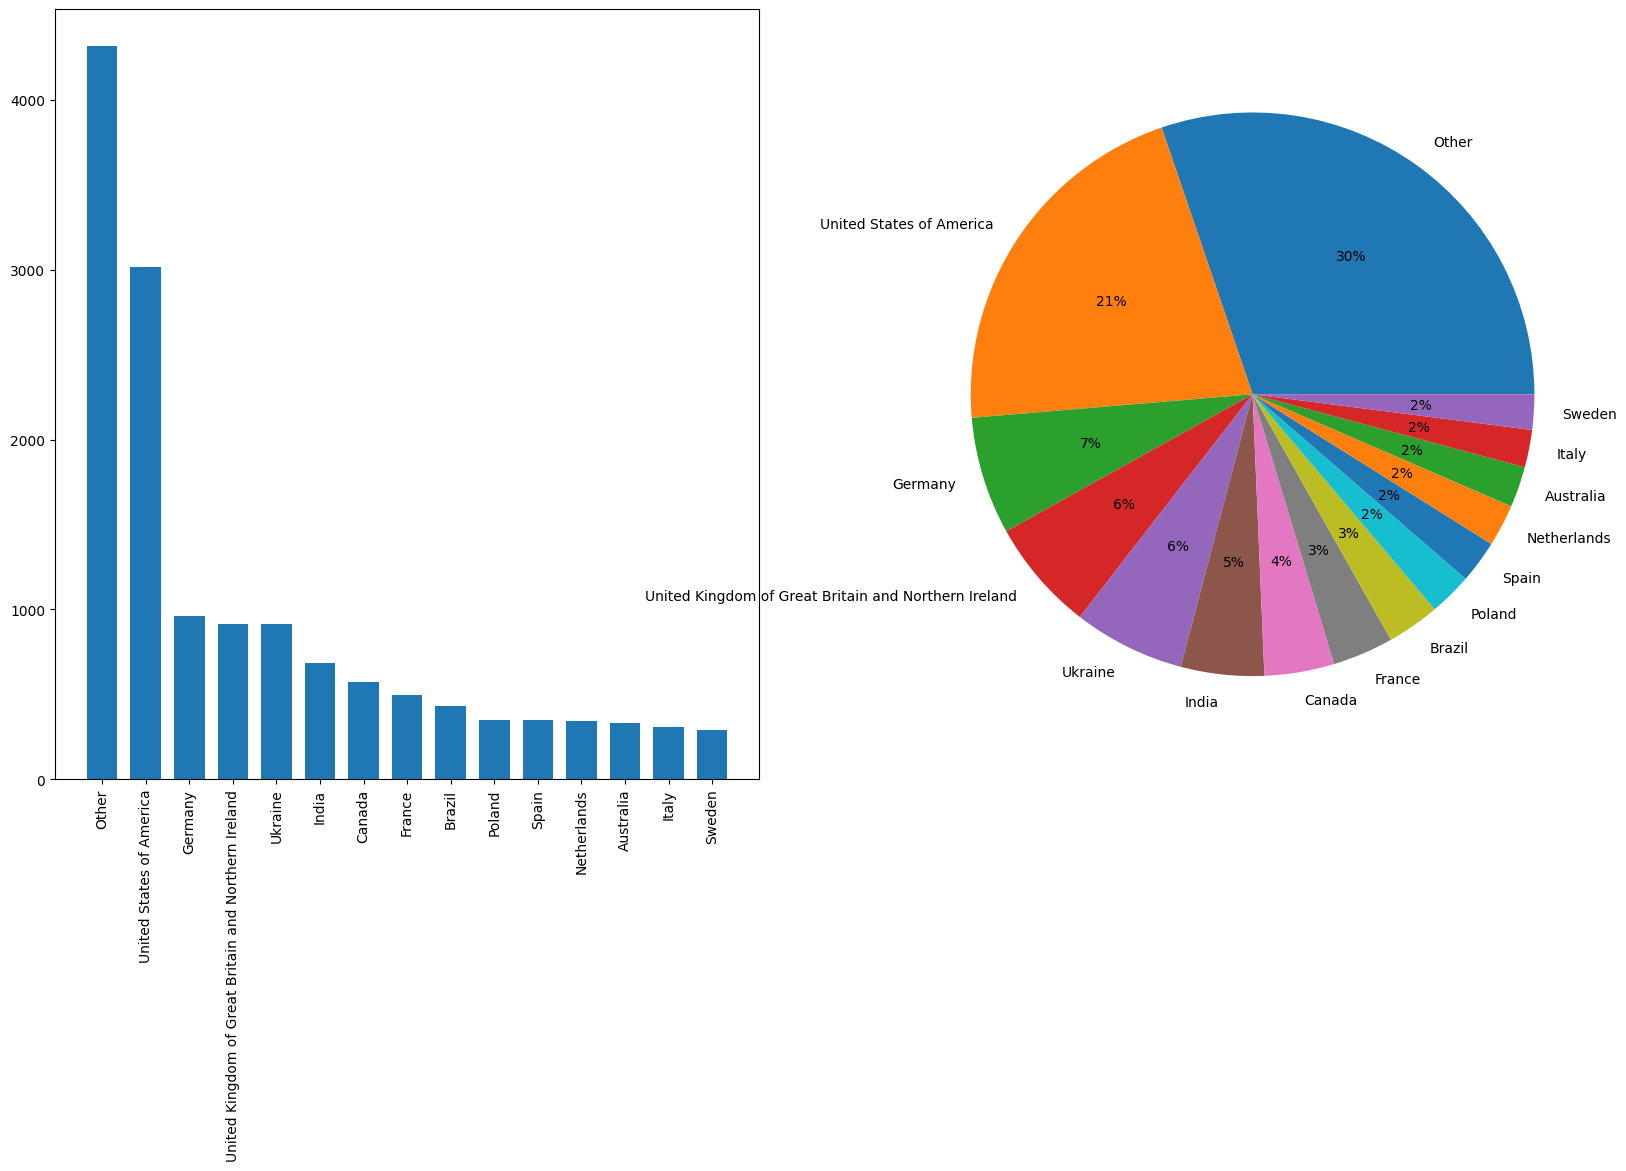

In [8]:
country = full_df["Country"].value_counts()

label = country.index
value = country.values

plt.figure(figsize=(20, 10))
plt.subplot(1,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

plt.show()

5. YearCodePro

In [9]:
full_df["YearCodePro"] = full_df["YearsCodePro"].apply(YearCodeProProcess)

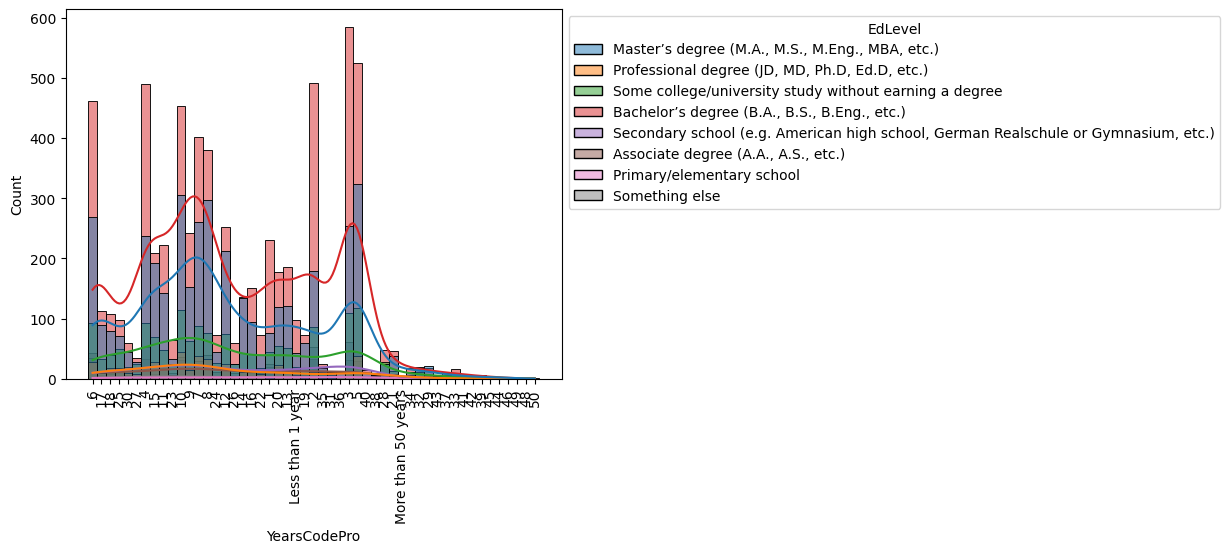

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.histplot(data=full_df, x="YearsCodePro", hue="EdLevel", kde=True, bins=30)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=90)      # Rotate x-axis labels
plt.show()


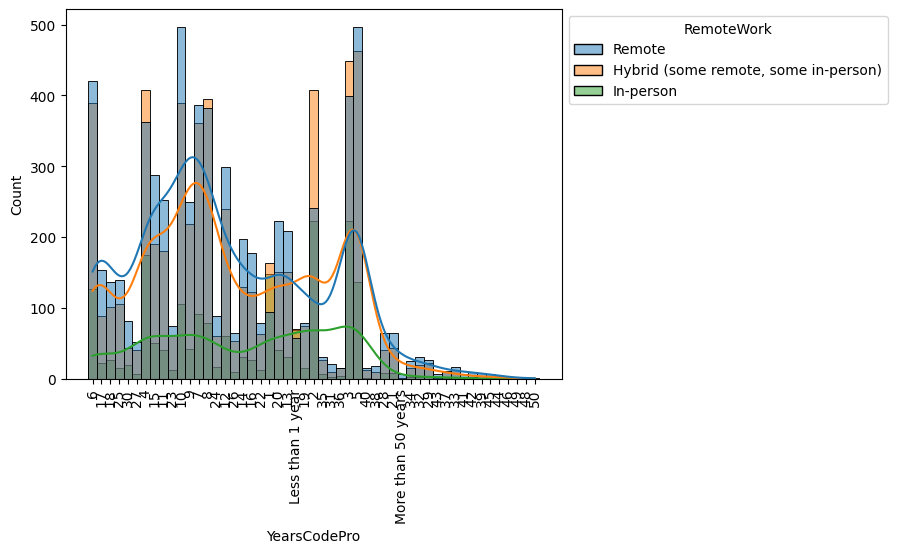

In [11]:
ax = sns.histplot(data=full_df, x="YearsCodePro", hue="RemoteWork", kde=True, bins=30)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=90)      # Rotate x-axis labels
plt.show()

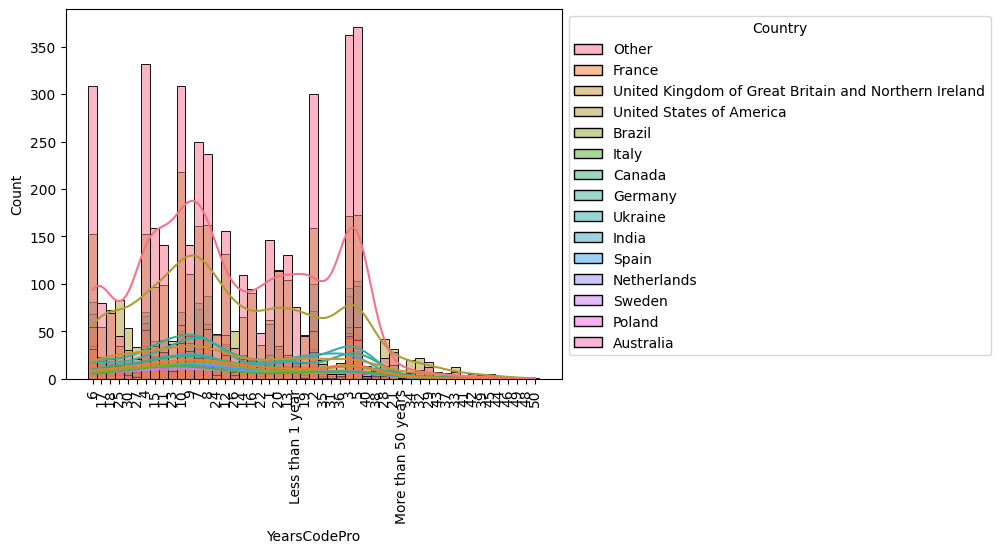

In [12]:
ax = sns.histplot(data=full_df, x="YearsCodePro", hue="Country", kde=True, bins=30)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=90) 
plt.show()

6. DevType

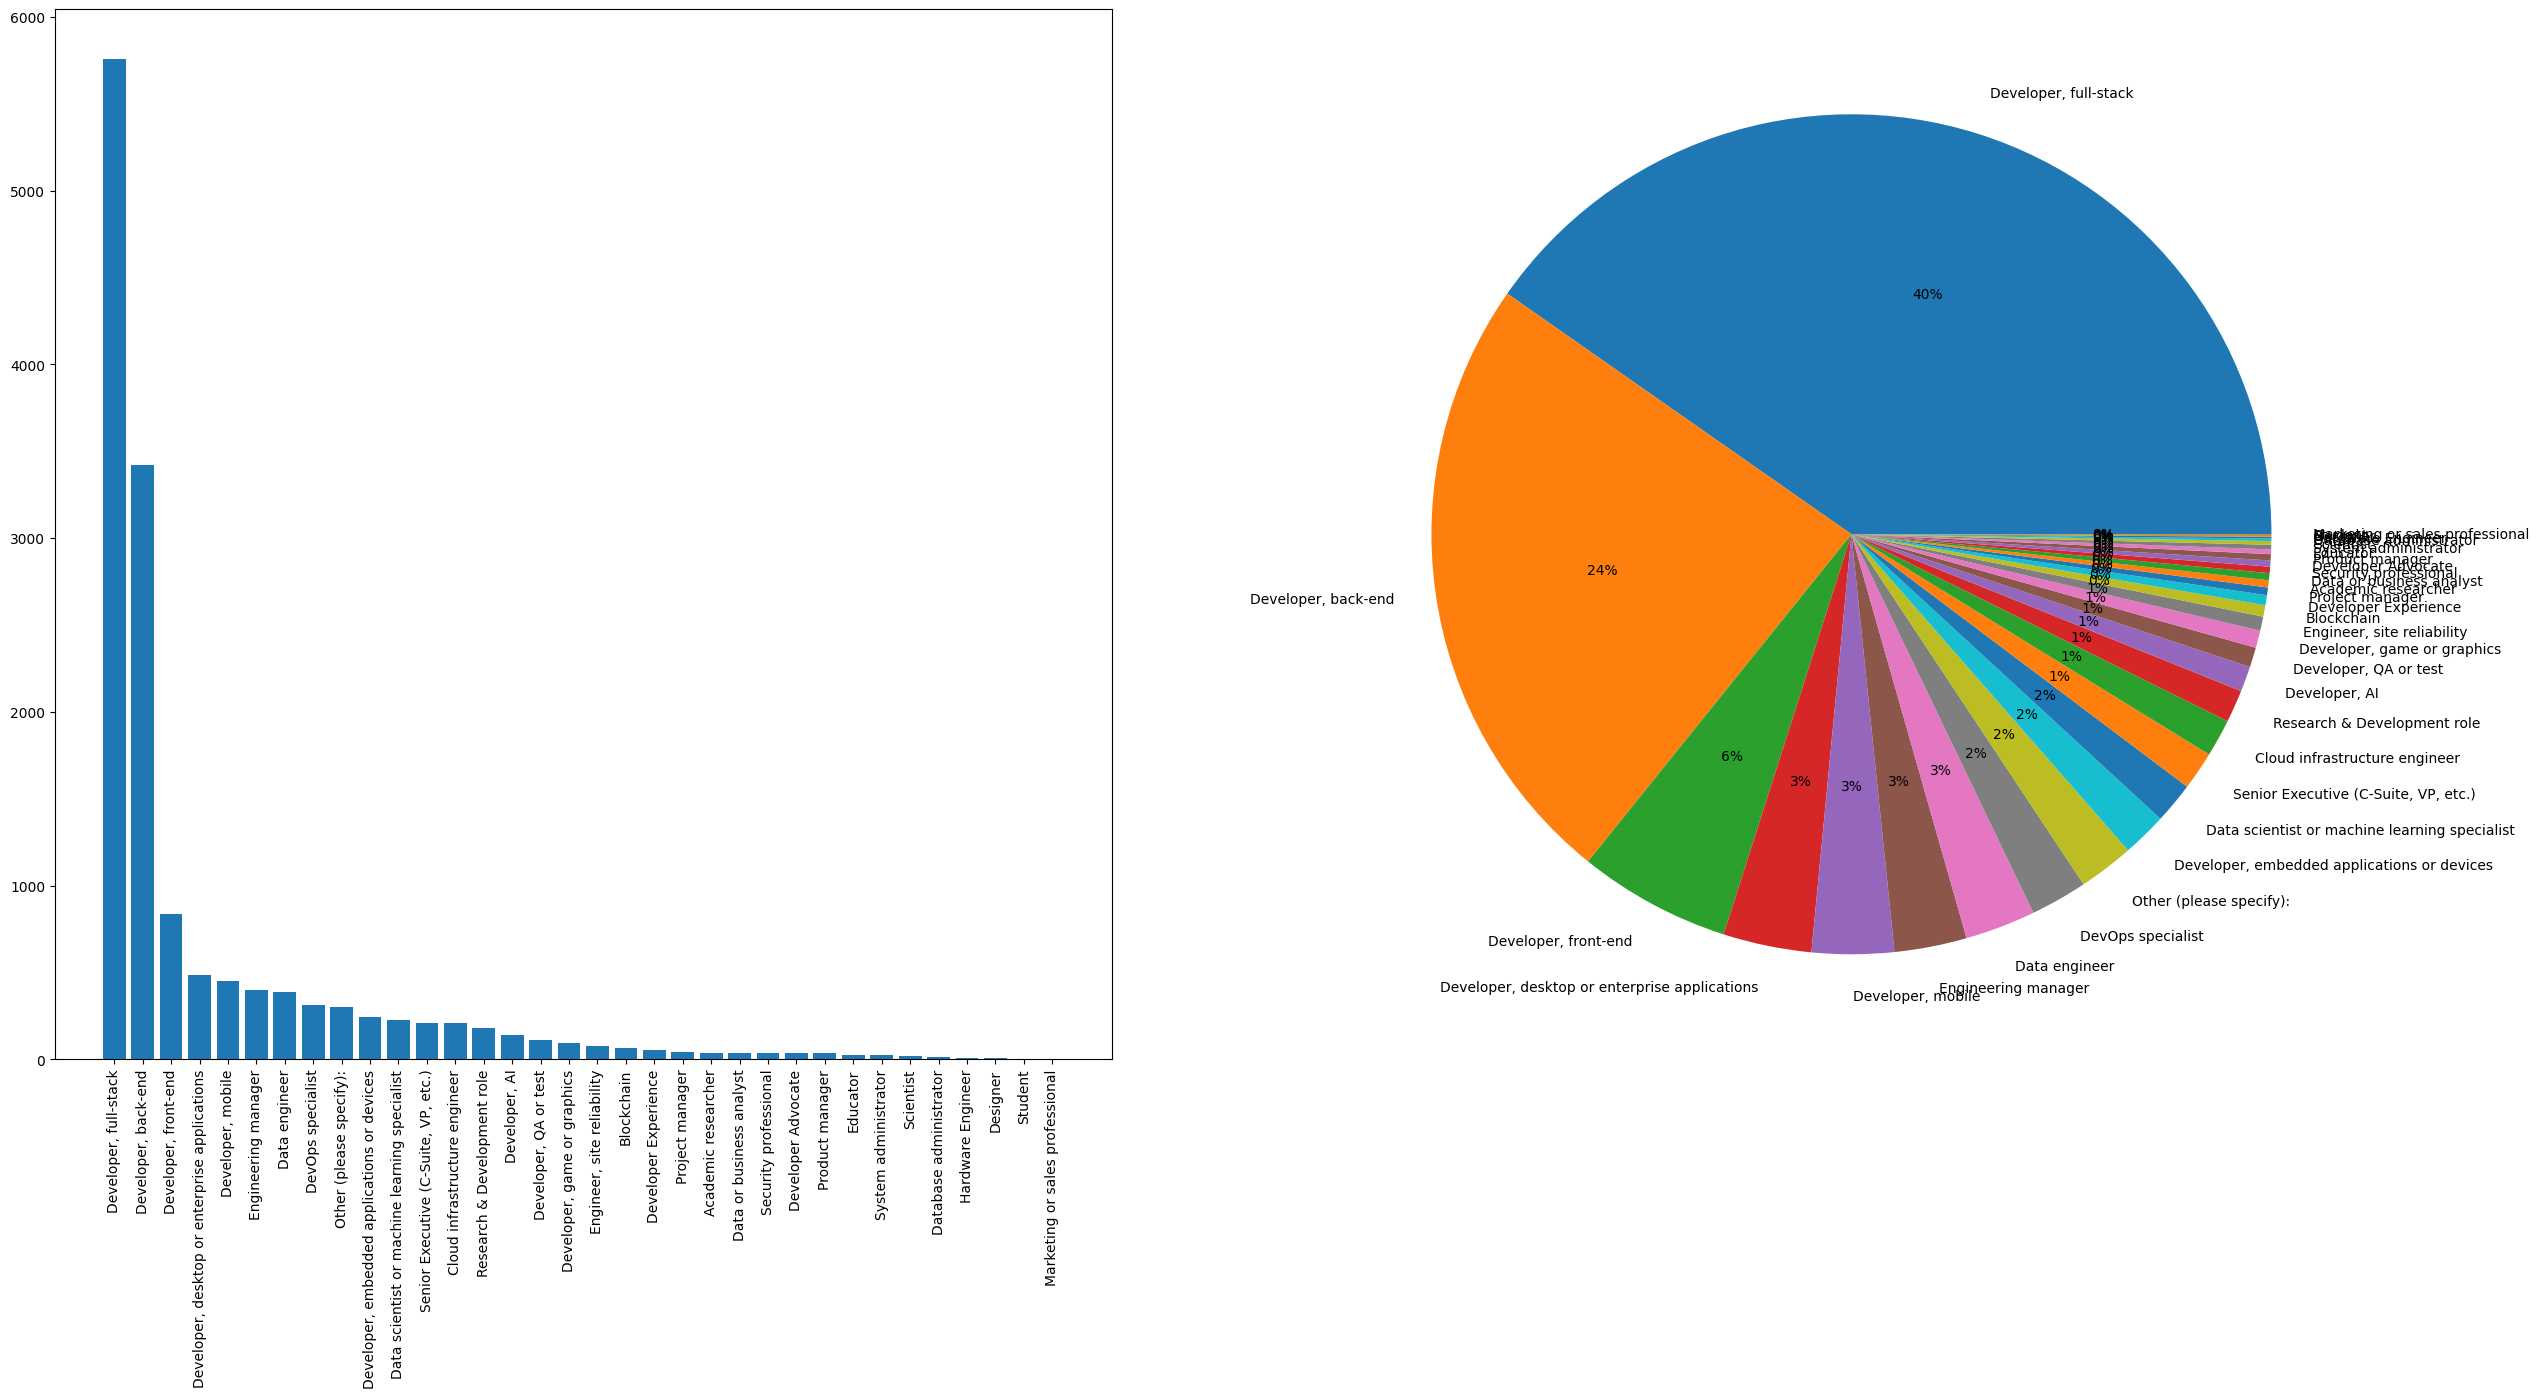

In [13]:
dev_type = split_multicolumn(full_df["DevType"])
dev_type_sum = dev_type.sum().sort_values(ascending=False)
label = dev_type_sum.index
value = dev_type_sum.values

plt.figure(figsize=(30, 30))
plt.subplot(2,2,1)
plt.bar(label, value, width=0.8)
plt.xticks(rotation=90)

plt.subplot(2,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

# plt.subplot(2,2,3)
# sns.heatmap(dev_type.corr())

plt.show()

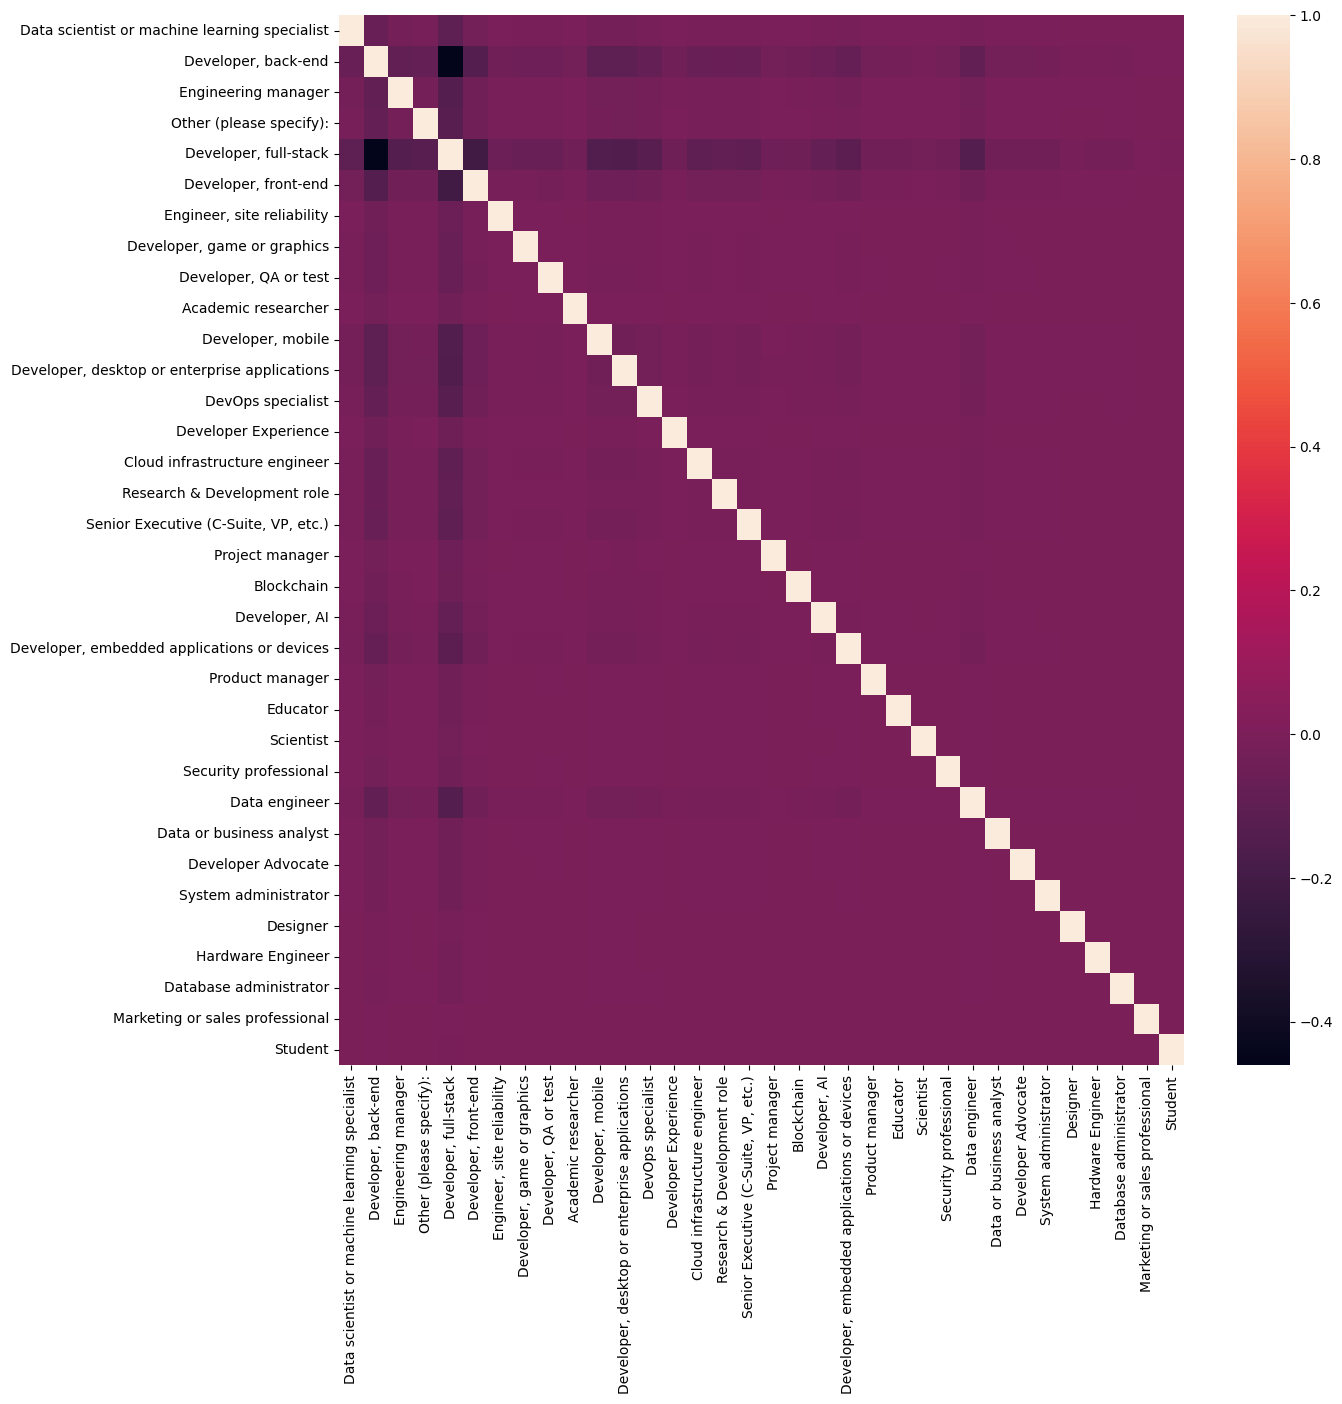

In [14]:
plt.figure(figsize=(30, 30))
plt.subplot(2,2,3)
sns.heatmap(dev_type.corr())

plt.show()

7. LanguageHaveWorkedWith

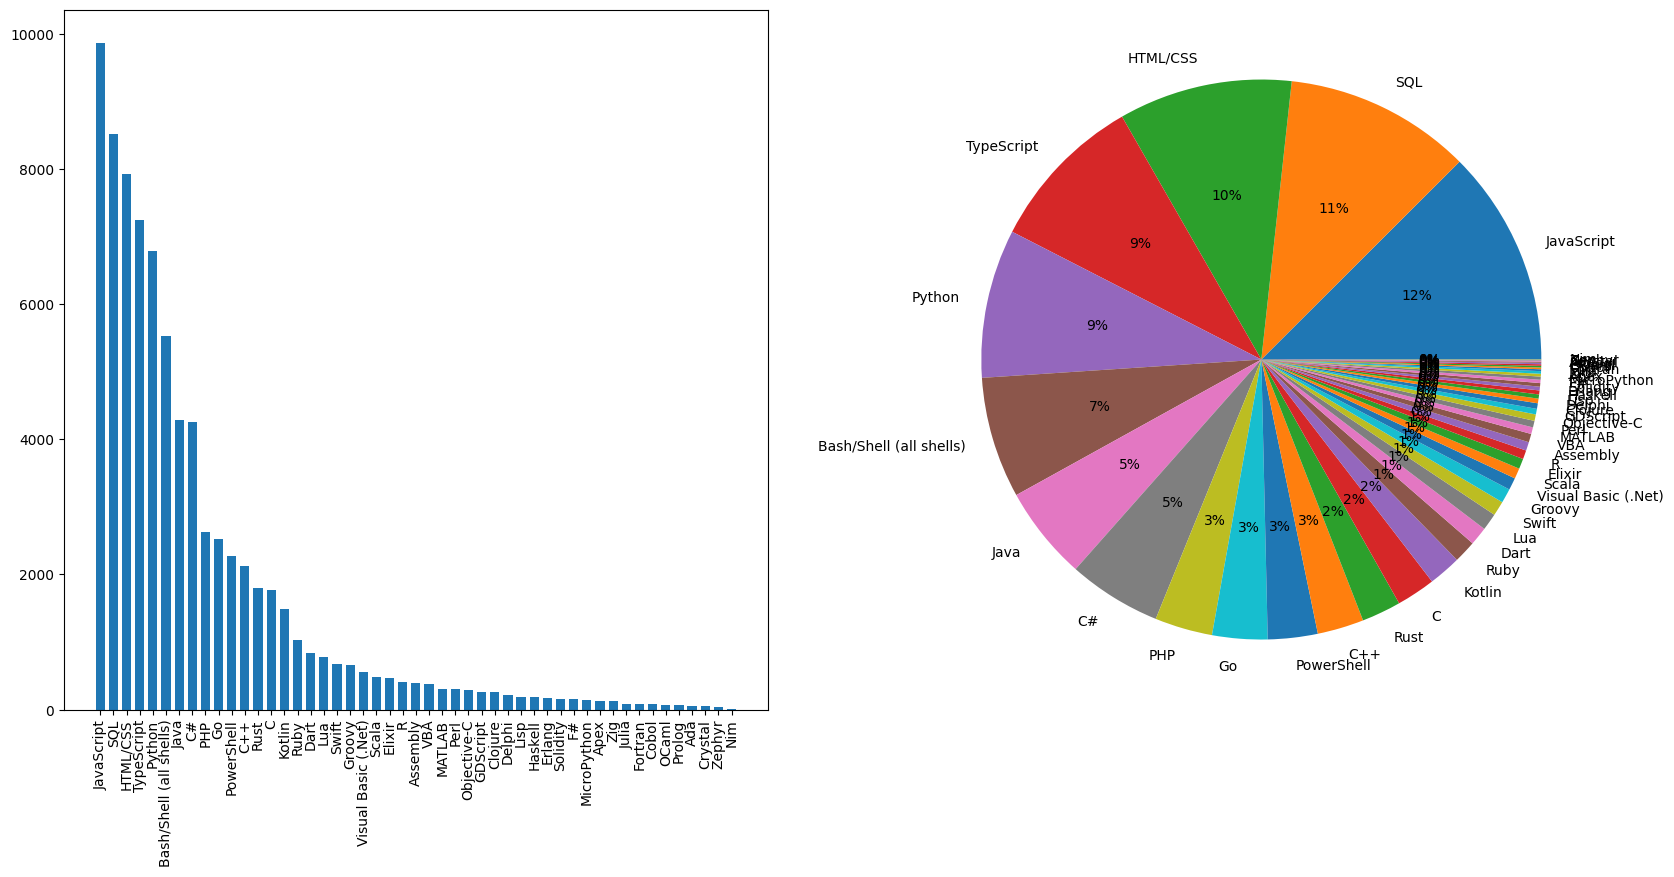

In [15]:
language = split_multicolumn(full_df["LanguageHaveWorkedWith"])
language_sum = language.sum().sort_values(ascending=False)

label = language_sum.index
value = language_sum.values

plt.figure(figsize=(20, 20))
plt.subplot(2,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(2,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')
plt.show()

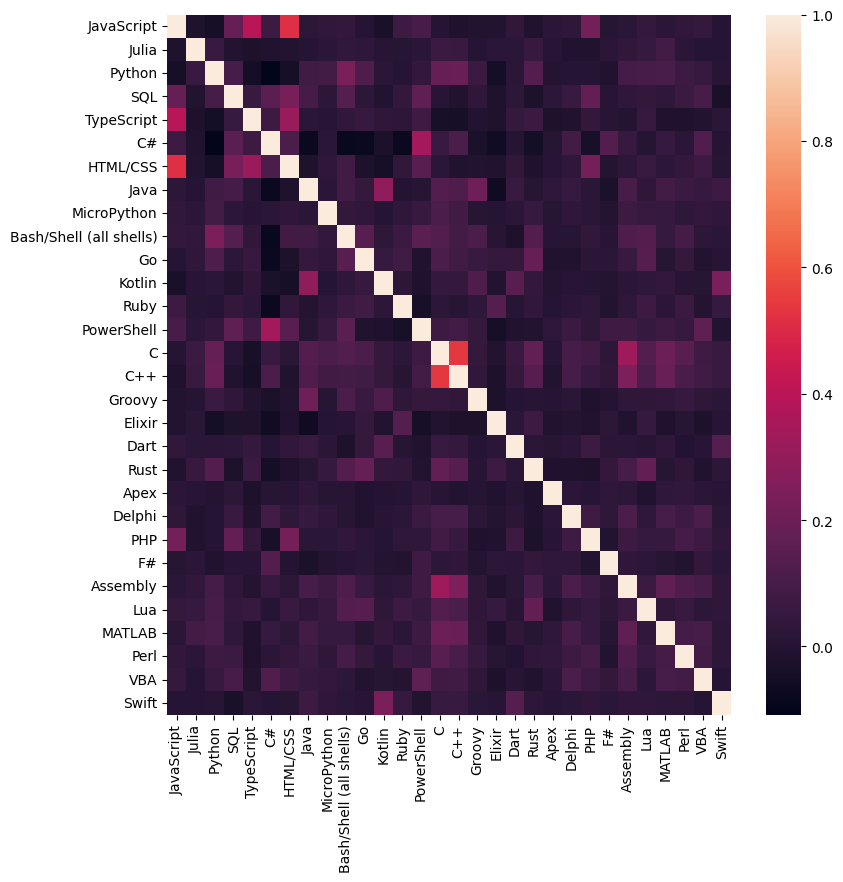

In [16]:
plt.figure(figsize=(20, 20))

plt.subplot(2,2,4)
sns.heatmap(language.iloc[:, :30].corr())

plt.show()


8. PlatformHaveWorkedWith

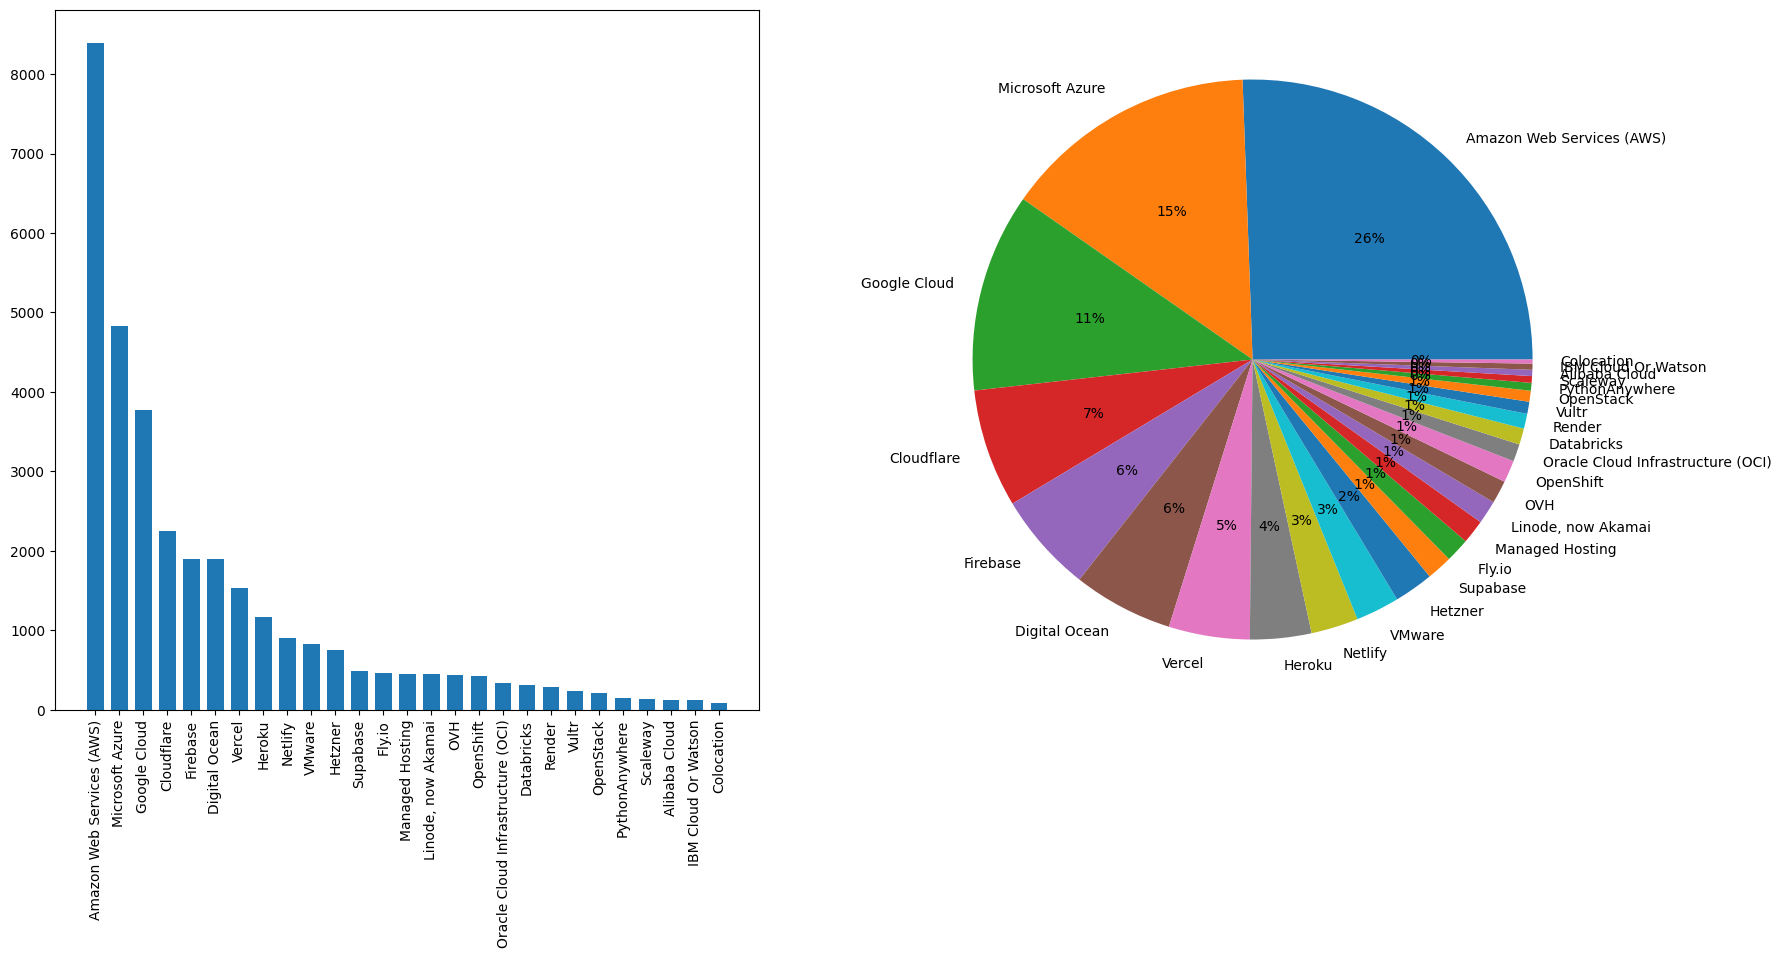

In [17]:
platform = split_multicolumn(full_df["PlatformHaveWorkedWith"])
platform_sum = platform.sum().sort_values(ascending=False)

label = platform_sum.index
value = platform_sum.values

plt.figure(figsize=(20, 20))
plt.subplot(2,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(2,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

plt.show()

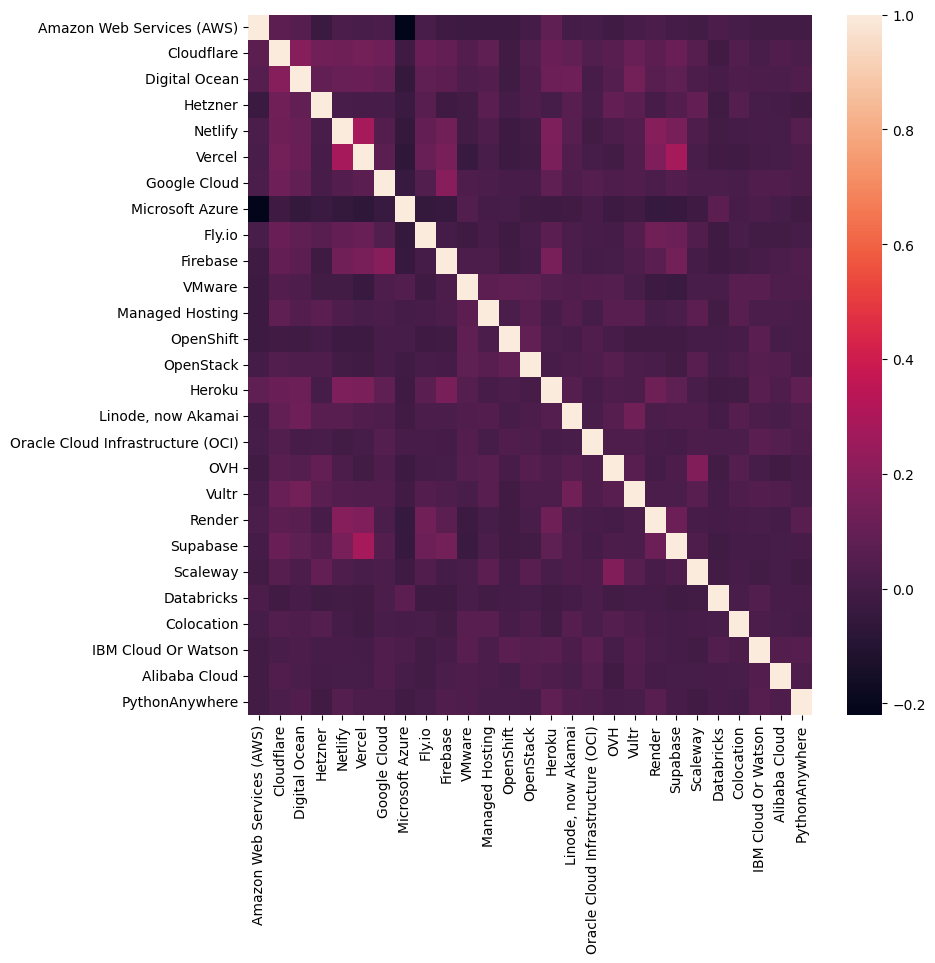

In [18]:
plt.figure(figsize=(20, 20))
plt.subplot(2,2,4)
sns.heatmap(platform.iloc[:, :30].corr())

plt.show()

9. ToolsTechHaveWorkedWith

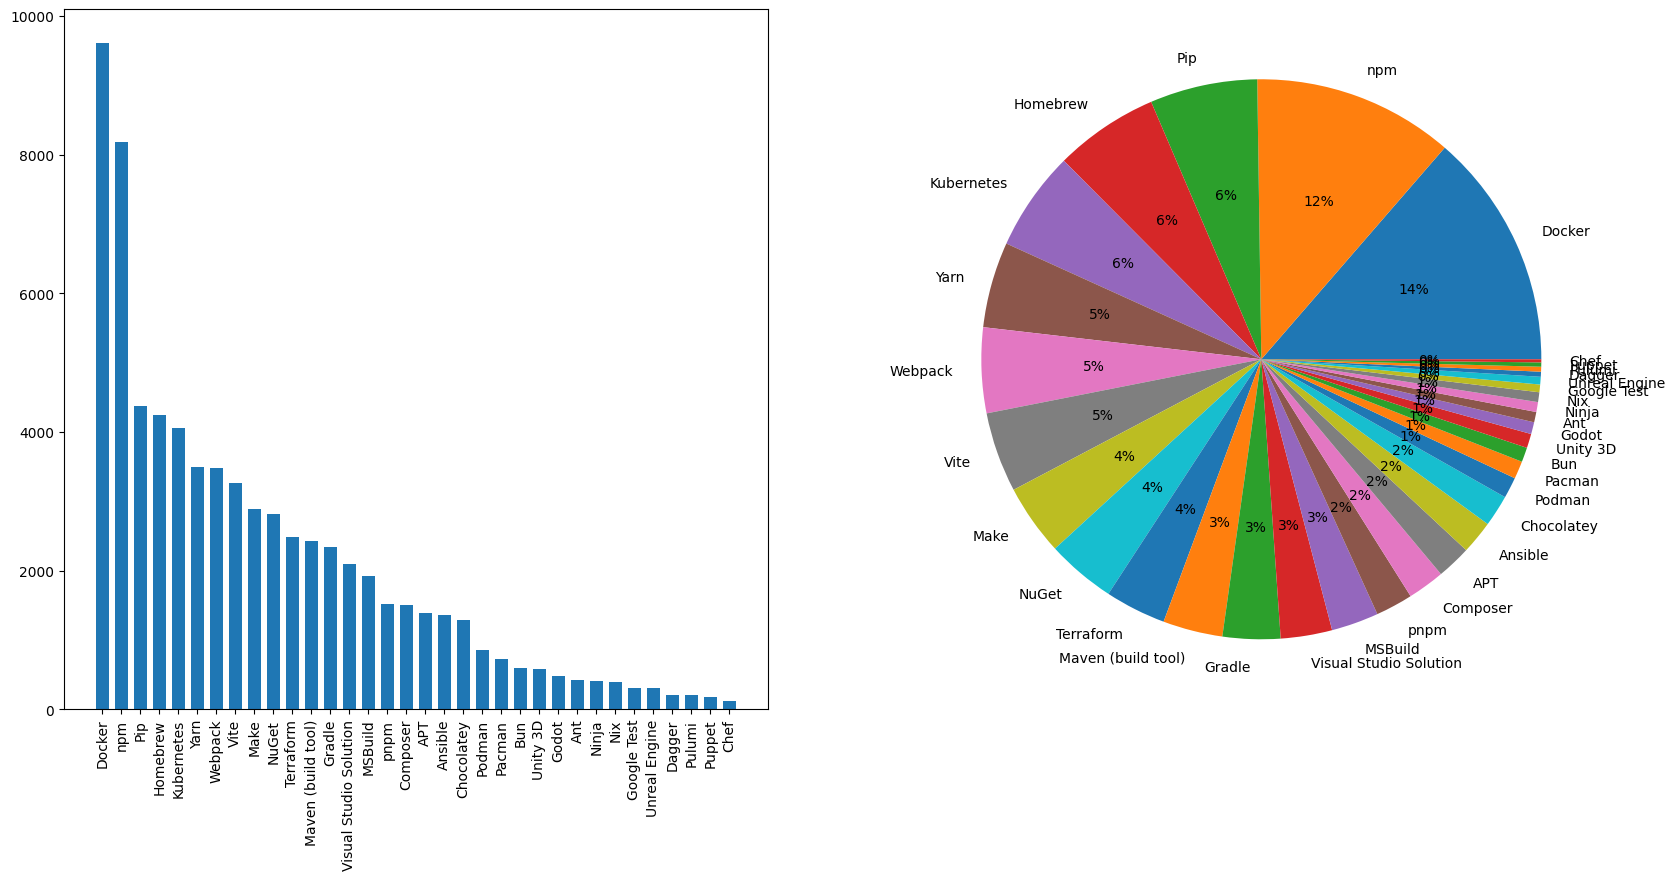

In [19]:
tool = split_multicolumn(full_df["ToolsTechHaveWorkedWith"])
tool_sum = tool.sum().sort_values(ascending=False)

label = tool_sum.index
value = tool_sum.values

plt.figure(figsize=(20, 20))
plt.subplot(2,2,1)
plt.bar(label, value, width=0.7)
plt.xticks(rotation=90)

plt.subplot(2,2,2)
plt.pie(x=value, labels=label, autopct='%.0f%%')

plt.show()

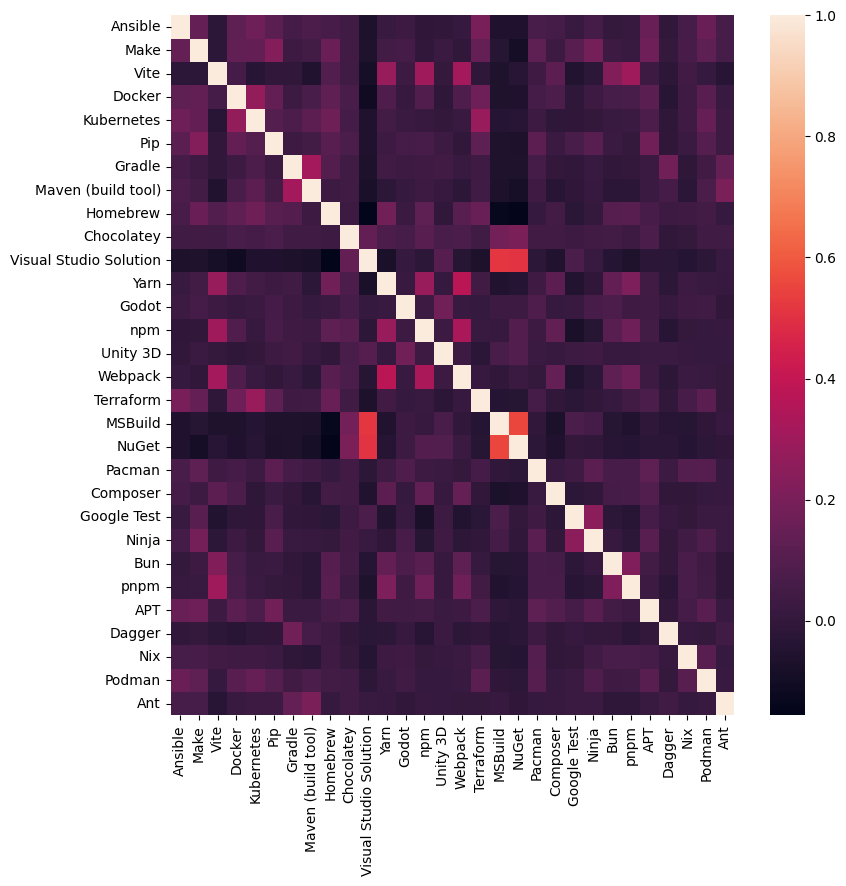

In [20]:
plt.figure(figsize=(20, 20))

plt.subplot(2,2,4)
sns.heatmap(tool.iloc[:, :30].corr())

plt.show()

10. Salary

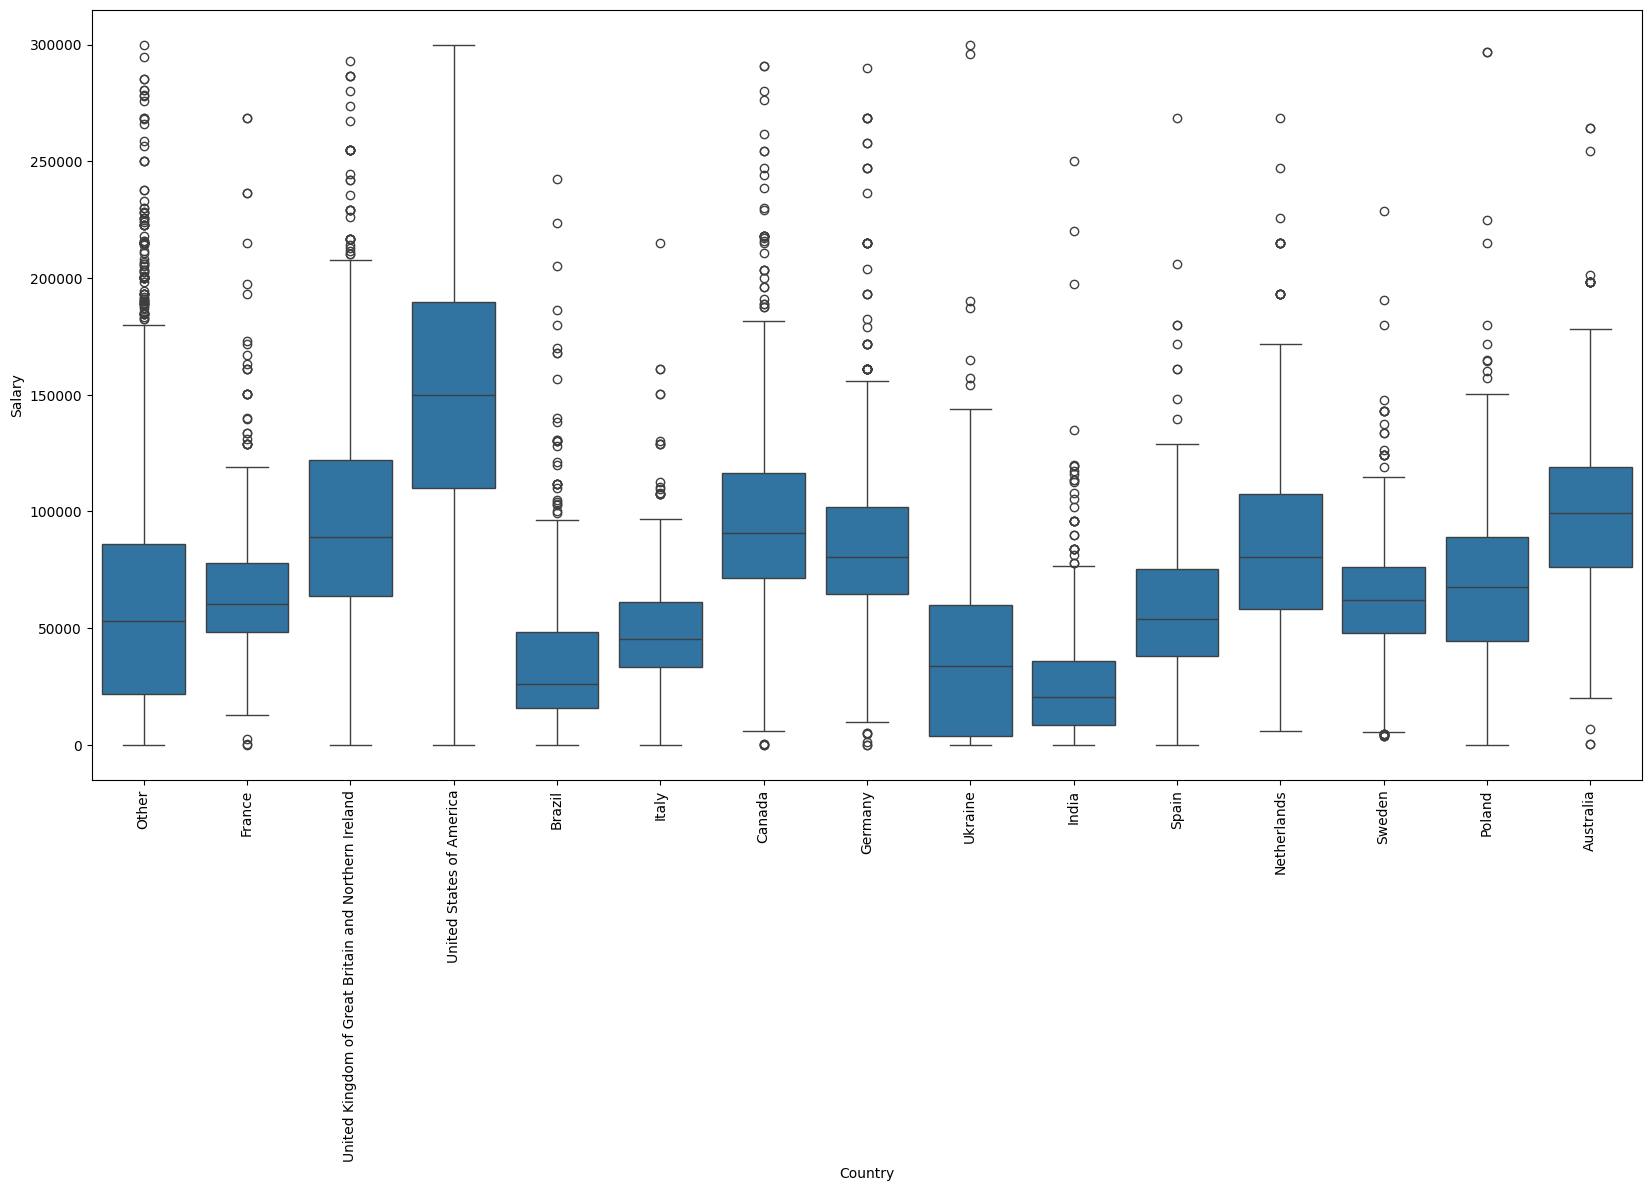

In [21]:
temp_df = full_df.copy()
temp_df = temp_df[temp_df["Salary"] <= 0.3*1e6]
plt.figure(figsize=(20, 10))
sns.boxplot(data=temp_df, x="Country", y="Salary")
plt.xticks(rotation=90)
plt.show()

In [22]:
df = load_df()
print(f"Dataframe shape: {df.shape}")
df.head(3)

Dataframe shape: (13956, 86)


,RemoteWork,EdLevel,YearsCodePro,Country,Age,Salary,Data scientist or machine learning specialist,"Developer, back-end",Engineering manager,Other (please specify):,...,Terraform,Maven (build tool),Gradle,Visual Studio Solution,MSBuild,pnpm,Composer,APT,Ansible,Chocolatey
379,Remote,Master’s degree,6.0,Other,35-44 years old,91295.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
385,Remote,Master’s degree,17.0,France,35-44 years old,53703.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
392,"Hybrid (some remote, some in-person)",Post grad,18.0,United Kingdom of Great Britain and Northern I...,35-44 years old,161044.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


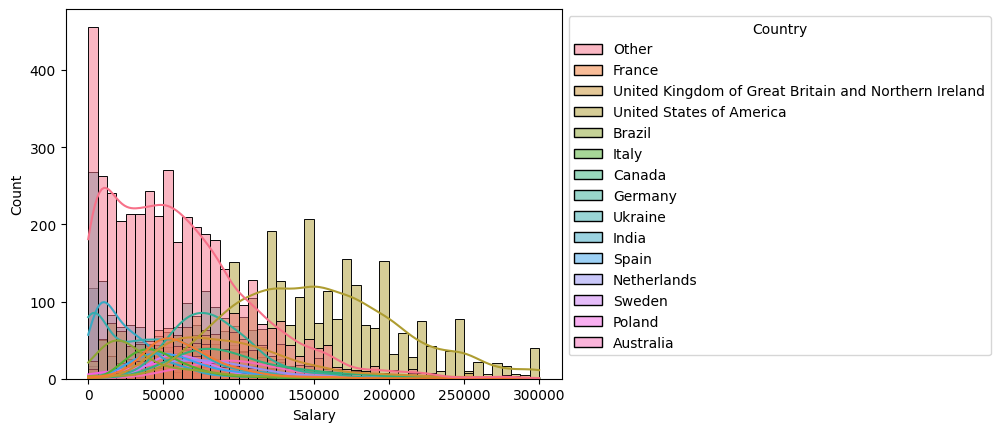

In [23]:
ax = sns.histplot(data=df, x="Salary", hue="Country", kde=True)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

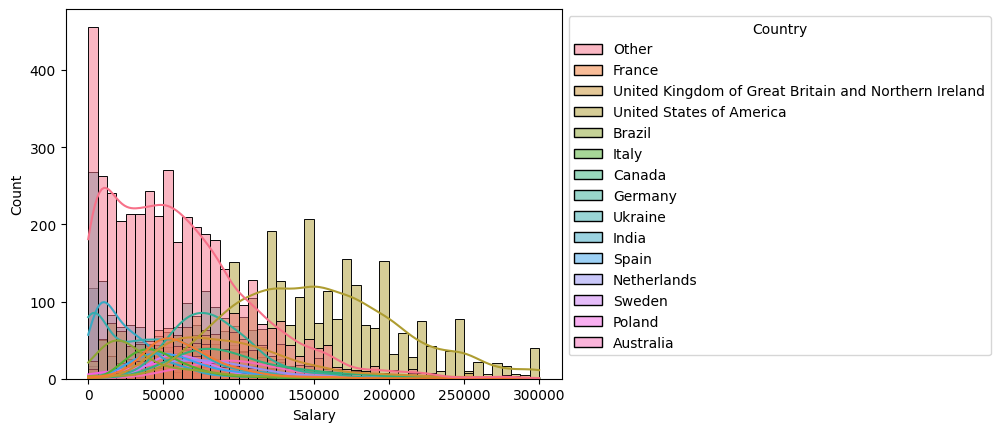

In [24]:
ax = sns.histplot(data=df, x="Salary", hue="Country", kde=True)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

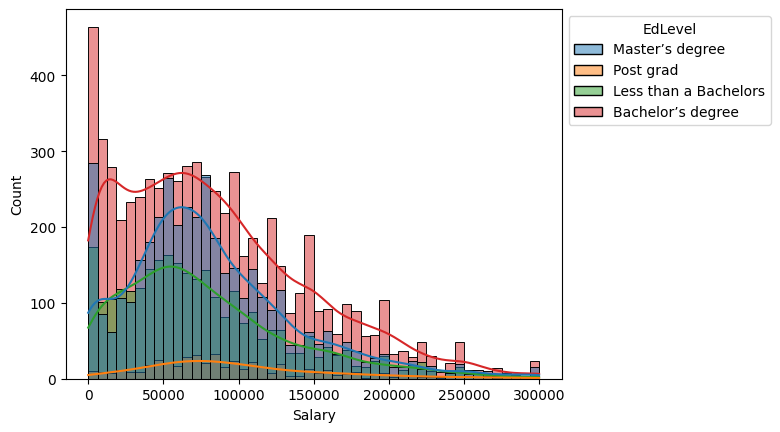

In [25]:
ax = sns.histplot(data=df, x="Salary", hue="EdLevel", kde=True)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

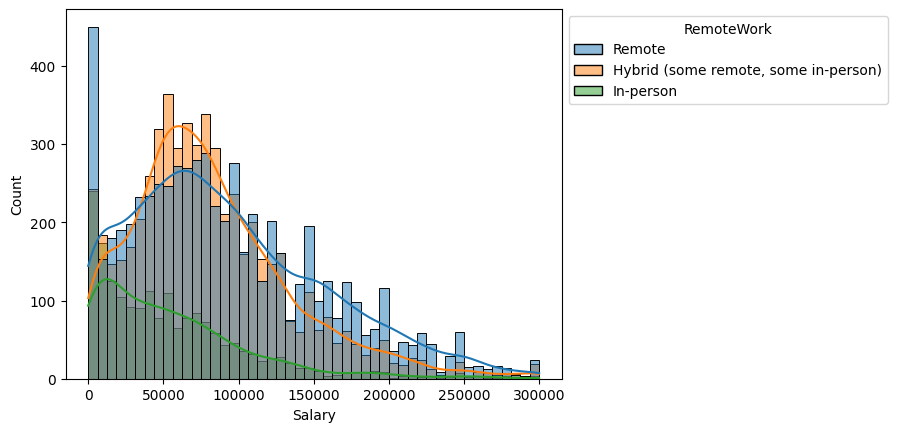

In [26]:
ax = sns.histplot(data=df, x="Salary", hue="RemoteWork", kde=True)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

# Data Preprocessing

The raw dataset contains categorical variables, multi-label fields, and inconsistencies that must be cleaned before modeling. To streamline this step, we implemented a preprocessing module with helper functions to handle different aspects of data transformation.

### Preprocessing Functions Overview

split_multicolumn(col_series): Expands multi-valued categorical fields (e.g., Languages, Tools, Platforms) into binary indicator columns.shorten_categories(categories, cutoff): Groups infrequent categorical values into an "Other" class based on a frequency cutoff.
age_process(val): Groups higher age categories (45+) into a single category "Over 45".
clean_education(x): Standardizes education levels into four categories: Less than a Bachelors, Bachelor’s degree, Master’s degree, Post grad.
YearCodeProProcess(x): Converts coding experience strings (e.g., "Less than 1 year", "More than 50 years") into numeric values.
remote_work_process(val): Normalizes remote work responses into "Remote", "Hybrid", or "In-person".


In [27]:
# preprocess.py

def split_multicolumn(col_series):
    result_df = col_series.to_frame()
    options = []
    for idx, value in col_series[col_series.notnull()].items():
        for option in value.split(';'):
            option = option.strip()  # Strip leading/trailing spaces
            if option not in result_df.columns:
                options.append(option)
                result_df[option] = 0.0
            result_df.at[idx, option] = 1.0
    return result_df[options]

def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories.values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = 'Other'
    return categorical_map

def age_process(val):
    if val == "45-54 years old" or val == "55-64 years old":
        return "Over 45"
    return val

def clean_education(x):
    if 'Bachelor’s degree' in x:
        return 'Bachelor’s degree'
    if 'Master’s degree' in x:
        return 'Master’s degree'
    if 'Professional degree' in x or 'Other doctoral' in x:
        return 'Post grad'
    return 'Less than a Bachelors'

def YearCodeProProcess(x):
    if x == 'More than 50 years':
        return 50
    if x == 'Less than 1 year':
        return 0.5
    return float(x)

def remote_work_process(val):
    if val == 'Hybrid (some remote, some in-person)':
        return "Hybrid"
    elif val == 'Fully remote':
        return "Remote"
    else:
        return "In-person"


# Model Implementation

To predict developer salaries, we first split the dataset into training and testing sets. Instead of scikit-learn’s train_test_split, we perform a 95/5 split manually for more control over the data distribution.

1. Train-Test Split

In [28]:
from dataset.load import load_df

In [29]:
df = load_df()
print(f"Dataframe shape: {df.shape}")
df.head(2)

Dataframe shape: (13956, 86)


,RemoteWork,EdLevel,YearsCodePro,Country,Age,Salary,Data scientist or machine learning specialist,"Developer, back-end",Engineering manager,Other (please specify):,...,Terraform,Maven (build tool),Gradle,Visual Studio Solution,MSBuild,pnpm,Composer,APT,Ansible,Chocolatey
379,Remote,Master’s degree,6.0,Other,35-44 years old,91295.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
385,Remote,Master’s degree,17.0,France,35-44 years old,53703.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
print("*" * 25)
train = df.sample(frac=0.95, random_state=42)
test = df.drop(train.index)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print("*" * 25)

X_train = train.drop(["Salary"], axis=1)
y_train = train["Salary"].values
X_test= test.drop(["Salary"], axis=1)
y_test = test["Salary"].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("*" * 25)

*************************
Train shape: (13258, 86)
Test shape: (698, 86)
*************************
X_train shape: (13258, 85)
y_train shape: (13258,)
X_test shape: (698, 85)
y_test shape: (698,)
*************************


2. Linear Regression

In [31]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler, MaxAbsScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import KFold, GridSearchCV

from dataset.load import load_df
from utils import evaluate


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# Preprocessing 
transform = ColumnTransformer([
    ("label", OrdinalEncoder(), ["EdLevel", "Country", "Age"]),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["RemoteWork"]),
    ("scaler", MaxAbsScaler(), ["YearsCodePro"])
], remainder="passthrough")

# Model
model = LinearRegression()

# Pipeline
pipe = Pipeline([
    ("preprocess", transform),
    ("model", model)
])

# Cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"]

scores = cross_validate(pipe, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=2)

# Evaluation
print("Linear Regression")
print(f"RMSE: mean: {-1 * np.mean(scores['test_neg_root_mean_squared_error'])} | {-1 * scores['test_neg_root_mean_squared_error']}")
print(f"MAE: mean: {-1 * np.mean(scores['test_neg_mean_absolute_error'])} | {-1 * scores['test_neg_mean_absolute_error']}")
print(f"R2-score: mean: {np.mean(scores['test_r2'])} | {scores['test_r2']}")
print("*" * 69)
print()


Linear Regression
RMSE: mean: 47531.68257902617 | [46821.92136037 46797.00200566 48593.53143934 47530.23517306
 47915.72291669]
MAE: mean: 36321.65512993515 | [35962.57906513 35983.26754477 36935.93731846 36283.68201902
 36442.8097023 ]
R2-score: mean: 0.3736649257877459 | [0.39904602 0.36144388 0.35986842 0.36204655 0.38591976]
*********************************************************************



3. RandomForest

In [32]:
transform = ColumnTransformer([
    ("label", OrdinalEncoder(), ["EdLevel", "Country", "Age"]),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["RemoteWork"]),
    ("scaler", MaxAbsScaler(), ["YearsCodePro"])
], remainder="passthrough")

model = RandomForestRegressor(n_estimators=200, n_jobs=2, random_state=42)

pipe = Pipeline([
    ("preprocess", transform),
    ("model", model)
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(pipe, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=2)
print("RandomForest")
print(f"RMSE: mean: {-1 * np.mean(scores['test_neg_root_mean_squared_error'])} | {-1 * scores['test_neg_root_mean_squared_error']}")
print(f"MAE: mean: {-1 * np.mean(scores['test_neg_mean_absolute_error'])} | {-1 * scores['test_neg_mean_absolute_error']}")
print(f"R2-score: mean: {np.mean(scores['test_r2'])} | {scores['test_r2']}")
print("*" * 69)
print()

RandomForest
RMSE: mean: 39077.85787325965 | [37865.42217418 38576.77836903 39521.51224995 39238.80010767
 40186.77646548]
MAE: mean: 28217.85134861315 | [27711.4030279  28261.66661388 28153.62949095 28277.99527537
 28684.56233497]
R2-score: mean: 0.5765743270095987 | [0.60696759 0.56607475 0.57657213 0.56520905 0.56804812]
*********************************************************************



#### Train and Save Models

1. Linear Regression

In [33]:
lr_model = LinearRegression()

lr_pipeline = Pipeline([
    ("preprocess", transform),
    ("model", lr_model)
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression Performance:")
evaluate(y_test, y_pred_lr)

# Save the pipeline to a file
# joblib.dump(lr_pipeline, "linear_regression_pipeline.pkl")
joblib.dump(lr_pipeline, "linear_regression_pipeline.joblib")

Linear Regression Performance:
                         Metrics        Values
0  Root Mean Square Error (RMSE)  46332.714199
1      Mean Absolute Error (MAE)  35543.970927
2                  R2-score (R2)      0.390412


['linear_regression_pipeline.joblib']

2. RandomForest

In [34]:
transform = ColumnTransformer([
    ("label", OrdinalEncoder(), ["EdLevel", "Country", "Age"]),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["RemoteWork"]),
    ("scaler", MaxAbsScaler(), ["YearsCodePro"])
], remainder="passthrough")

model = RandomForestRegressor(n_estimators=200, n_jobs=2, random_state=42)

pipe = Pipeline([
    ("preprocess", transform),
    ("model", model)
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(pipe, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=2)
print("RandomForest")
print(f"RMSE: mean: {-1 * np.mean(scores['test_neg_root_mean_squared_error'])} | {-1 * scores['test_neg_root_mean_squared_error']}")
print(f"MAE: mean: {-1 * np.mean(scores['test_neg_mean_absolute_error'])} | {-1 * scores['test_neg_mean_absolute_error']}")
print(f"R2-score: mean: {np.mean(scores['test_r2'])} | {scores['test_r2']}")
print("*" * 69)
print()

RandomForest
RMSE: mean: 39077.85787325965 | [37865.42217418 38576.77836903 39521.51224995 39238.80010767
 40186.77646548]
MAE: mean: 28217.85134861315 | [27711.4030279  28261.66661388 28153.62949095 28277.99527537
 28684.56233497]
R2-score: mean: 0.5765743270095987 | [0.60696759 0.56607475 0.57657213 0.56520905 0.56804812]
*********************************************************************



# Model Evaluation and Discussion

### Model Evaluation

This section provides comprehensive performance analysis for Linear Regression and Random Forest models.

In [35]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    explained_variance_score
)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [36]:
# Load the dataset 
from dataset.load import load_df

# Load data and create train-test split 
df = load_df()
train = df.sample(frac=0.95, random_state=42)
test = df.drop(train.index)

X_train = train.drop(["Salary"], axis=1)
y_train = train["Salary"].values
X_test = test.drop(["Salary"], axis=1)
y_test = test["Salary"].values

print(f"Test set size: {len(y_test)} samples")
print(f"Salary range in test set: ${y_test.min():,.0f} - ${y_test.max():,.0f}")

Test set size: 698 samples
Salary range in test set: $1 - $300,000


In [37]:
# Load trained models
try:
    lr_pipeline = joblib.load("linear_regression_pipeline.joblib")
    rf_pipeline = joblib.load("best_model_original_rf.joblib")
    print("Models loaded successfully!")
except FileNotFoundError as e:
    print(f"Model file not found: {e}")
    print("Please make sure you have run the training script first.")

Models loaded successfully!


In [39]:
# Generate predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

print("Predictions generated successfully!")
print(f"Linear Regression predictions range: ${y_pred_lr.min():,.0f} - ${y_pred_lr.max():,.0f}")
print(f"Random Forest predictions range: ${y_pred_rf.min():,.0f} - ${y_pred_rf.max():,.0f}")

Predictions generated successfully!
Linear Regression predictions range: $-10,405 - $208,643
Random Forest predictions range: $9,476 - $204,933


In [40]:
def calculate_comprehensive_metrics(y_true, y_pred, model_name):
    """
    Calculate comprehensive performance metrics for regression models with robust MAPE alternatives
    """
    # Calculate individual percentage errors
    individual_errors = np.abs((y_true - y_pred) / y_true) * 100
    
    # Use Median APE 
    median_ape = np.median(individual_errors)
    
    # Calculate MAPE only for reasonable salary ranges (> $15K to avoid extreme percentages)
    reasonable_salary_mask = y_true > 15000
    if np.sum(reasonable_salary_mask) > 0:
        filtered_mape = np.mean(individual_errors[reasonable_salary_mask])
    else:
        filtered_mape = np.inf
    
    # Calculate what percentage of predictions are within reasonable error 
    within_20_pct = (individual_errors <= 20).sum() / len(individual_errors) * 100
    within_30_pct = (individual_errors <= 30).sum() / len(individual_errors) * 100
    
    metrics = {
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'Median APE (%)': median_ape, 
        'MAPE >$15K (%)': filtered_mape,  # MAPE for salaries > $15K only
        'Within 20% (%)': within_20_pct,  # Percentage of predictions within 20% error
        'Within 30% (%)': within_30_pct,  # Percentage of predictions within 30% error
        'Explained Variance': explained_variance_score(y_true, y_pred),
        'Max Error': np.max(np.abs(y_true - y_pred)),
        'Mean Error': np.mean(y_true - y_pred),
        'Std Error': np.std(y_true - y_pred),
        'Pearson Correlation': pearsonr(y_true, y_pred)[0]
    }
    return metrics

# Calculate metrics for both models
lr_metrics = calculate_comprehensive_metrics(y_test, y_pred_lr, 'Linear Regression')
rf_metrics = calculate_comprehensive_metrics(y_test, y_pred_rf, 'Random Forest')

# Create comparison dataframe
metrics_df = pd.DataFrame([lr_metrics, rf_metrics])
metrics_df = metrics_df.round(3)

print("\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE METRICS COMPARISON")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)


COMPREHENSIVE PERFORMANCE METRICS COMPARISON
            Model      RMSE       MAE    R²  Median APE (%)  MAPE >$15K (%)  Within 20% (%)  Within 30% (%)  Explained Variance  Max Error  Mean Error  Std Error  Pearson Correlation
Linear Regression 46332.714 35543.971 0.390          39.110          49.846          27.364          41.261               0.391 227534.121    -625.201  46328.496                0.625
    Random Forest 32861.217 22906.022 0.693          23.618          31.074          42.837          59.885               0.694 263284.739    1227.531  32838.281                0.837


In [41]:
# Performance improvement analysis
print("\n" + "="*60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*60)

rmse_improvement = ((lr_metrics['RMSE'] - rf_metrics['RMSE']) / lr_metrics['RMSE']) * 100
mae_improvement = ((lr_metrics['MAE'] - rf_metrics['MAE']) / lr_metrics['MAE']) * 100
r2_improvement = ((rf_metrics['R²'] - lr_metrics['R²']) / lr_metrics['R²']) * 100

# Use Median APE for comparison
median_ape_improvement = ((lr_metrics['Median APE (%)'] - rf_metrics['Median APE (%)']) / lr_metrics['Median APE (%)']) * 100

print(f"Random Forest vs Linear Regression:")
print(f"• RMSE improved by: {rmse_improvement:.1f}%")
print(f"• MAE improved by: {mae_improvement:.1f}%")
print(f"• R² improved by: {r2_improvement:.1f}%")
print(f"• Median APE improved by: {median_ape_improvement:.1f}%")

# Error analysis
lr_errors = y_test - y_pred_lr
rf_errors = y_test - y_pred_rf

print(f"\nError Distribution Analysis:")
print(f"Linear Regression - Mean Error: ${lr_metrics['Mean Error']:,.0f}, Std: ${lr_metrics['Std Error']:,.0f}")
print(f"Random Forest - Mean Error: ${rf_metrics['Mean Error']:,.0f}, Std: ${rf_metrics['Std Error']:,.0f}")

print(f"\nPrediction Accuracy:")
print(f"Random Forest - {rf_metrics['Within 20% (%)']:.1f}% of predictions within 20% error")
print(f"Random Forest - {rf_metrics['Within 30% (%)']:.1f}% of predictions within 30% error")
print("="*60)


PERFORMANCE IMPROVEMENT ANALYSIS
Random Forest vs Linear Regression:
• RMSE improved by: 29.1%
• MAE improved by: 35.6%
• R² improved by: 77.6%
• Median APE improved by: 39.6%

Error Distribution Analysis:
Linear Regression - Mean Error: $-625, Std: $46,328
Random Forest - Mean Error: $1,228, Std: $32,838

Prediction Accuracy:
Random Forest - 42.8% of predictions within 20% error
Random Forest - 59.9% of predictions within 30% error


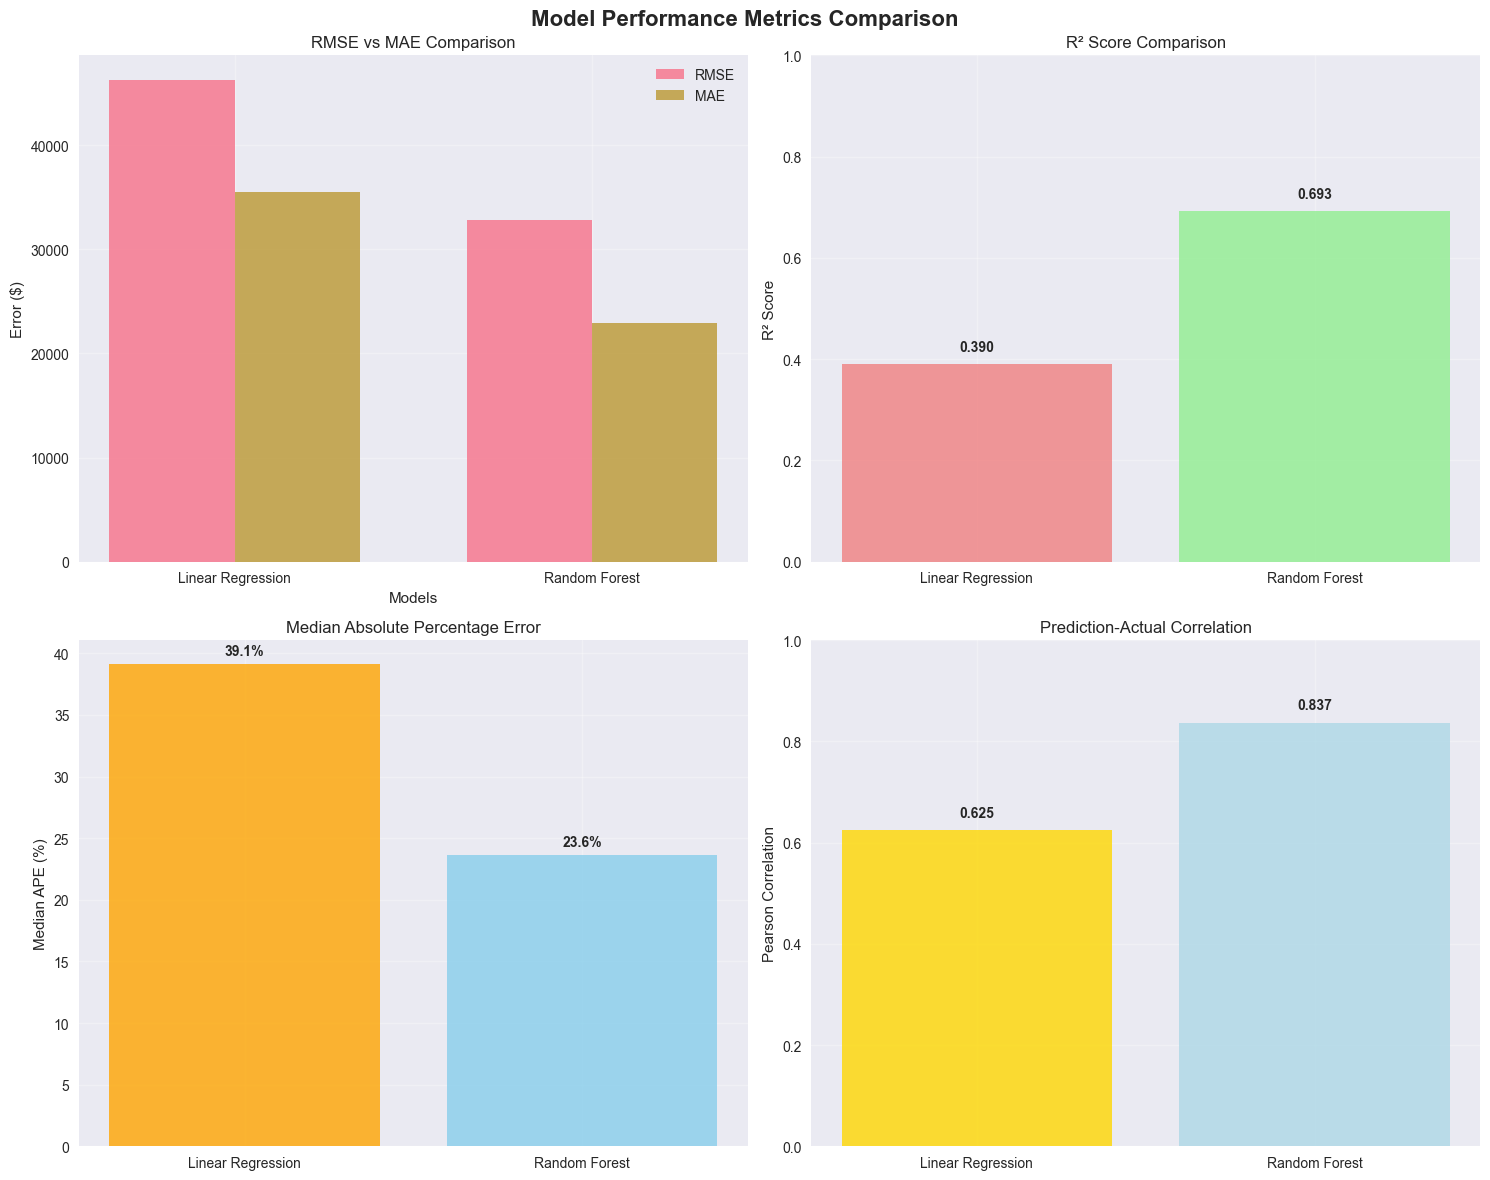

In [42]:
# Create a comprehensive metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')

# RMSE and MAE Comparison
models = ['Linear Regression', 'Random Forest']
rmse_values = [lr_metrics['RMSE'], rf_metrics['RMSE']]
mae_values = [lr_metrics['MAE'], rf_metrics['MAE']]

x = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x - width/2, rmse_values, width, label='RMSE', alpha=0.8)
axes[0, 0].bar(x + width/2, mae_values, width, label='MAE', alpha=0.8)
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('Error ($)')
axes[0, 0].set_title('RMSE vs MAE Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# R² Score Comparison
r2_values = [lr_metrics['R²'], rf_metrics['R²']]
colors = ['lightcoral', 'lightgreen']
axes[0, 1].bar(models, r2_values, color=colors, alpha=0.8)
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² Score Comparison')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(r2_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Median APE Comparison
median_ape_values = [lr_metrics['Median APE (%)'], rf_metrics['Median APE (%)']]
axes[1, 0].bar(models, median_ape_values, color=['orange', 'skyblue'], alpha=0.8)
axes[1, 0].set_ylabel('Median APE (%)')
axes[1, 0].set_title('Median Absolute Percentage Error')
axes[1, 0].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(median_ape_values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Correlation Comparison
corr_values = [lr_metrics['Pearson Correlation'], rf_metrics['Pearson Correlation']]
axes[1, 1].bar(models, corr_values, color=['gold', 'lightblue'], alpha=0.8)
axes[1, 1].set_ylabel('Pearson Correlation')
axes[1, 1].set_title('Prediction-Actual Correlation')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(corr_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

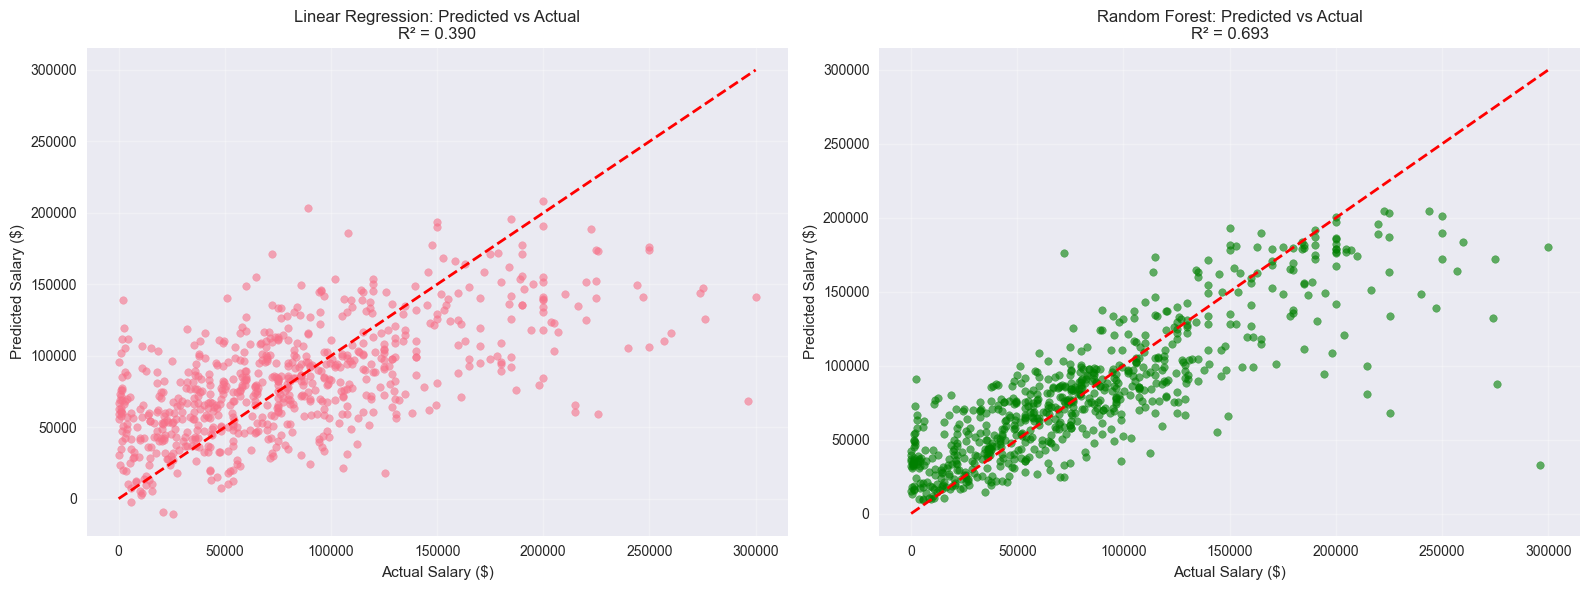

In [43]:
# Scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
ax1.scatter(y_test, y_pred_lr, alpha=0.6, s=30)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Salary ($)')
ax1.set_ylabel('Predicted Salary ($)')
ax1.set_title(f'Linear Regression: Predicted vs Actual\nR² = {lr_metrics["R²"]:.3f}')
ax1.grid(True, alpha=0.3)

# Random Forest
ax2.scatter(y_test, y_pred_rf, alpha=0.6, s=30, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Salary ($)')
ax2.set_ylabel('Predicted Salary ($)')
ax2.set_title(f'Random Forest: Predicted vs Actual\nR² = {rf_metrics["R²"]:.3f}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


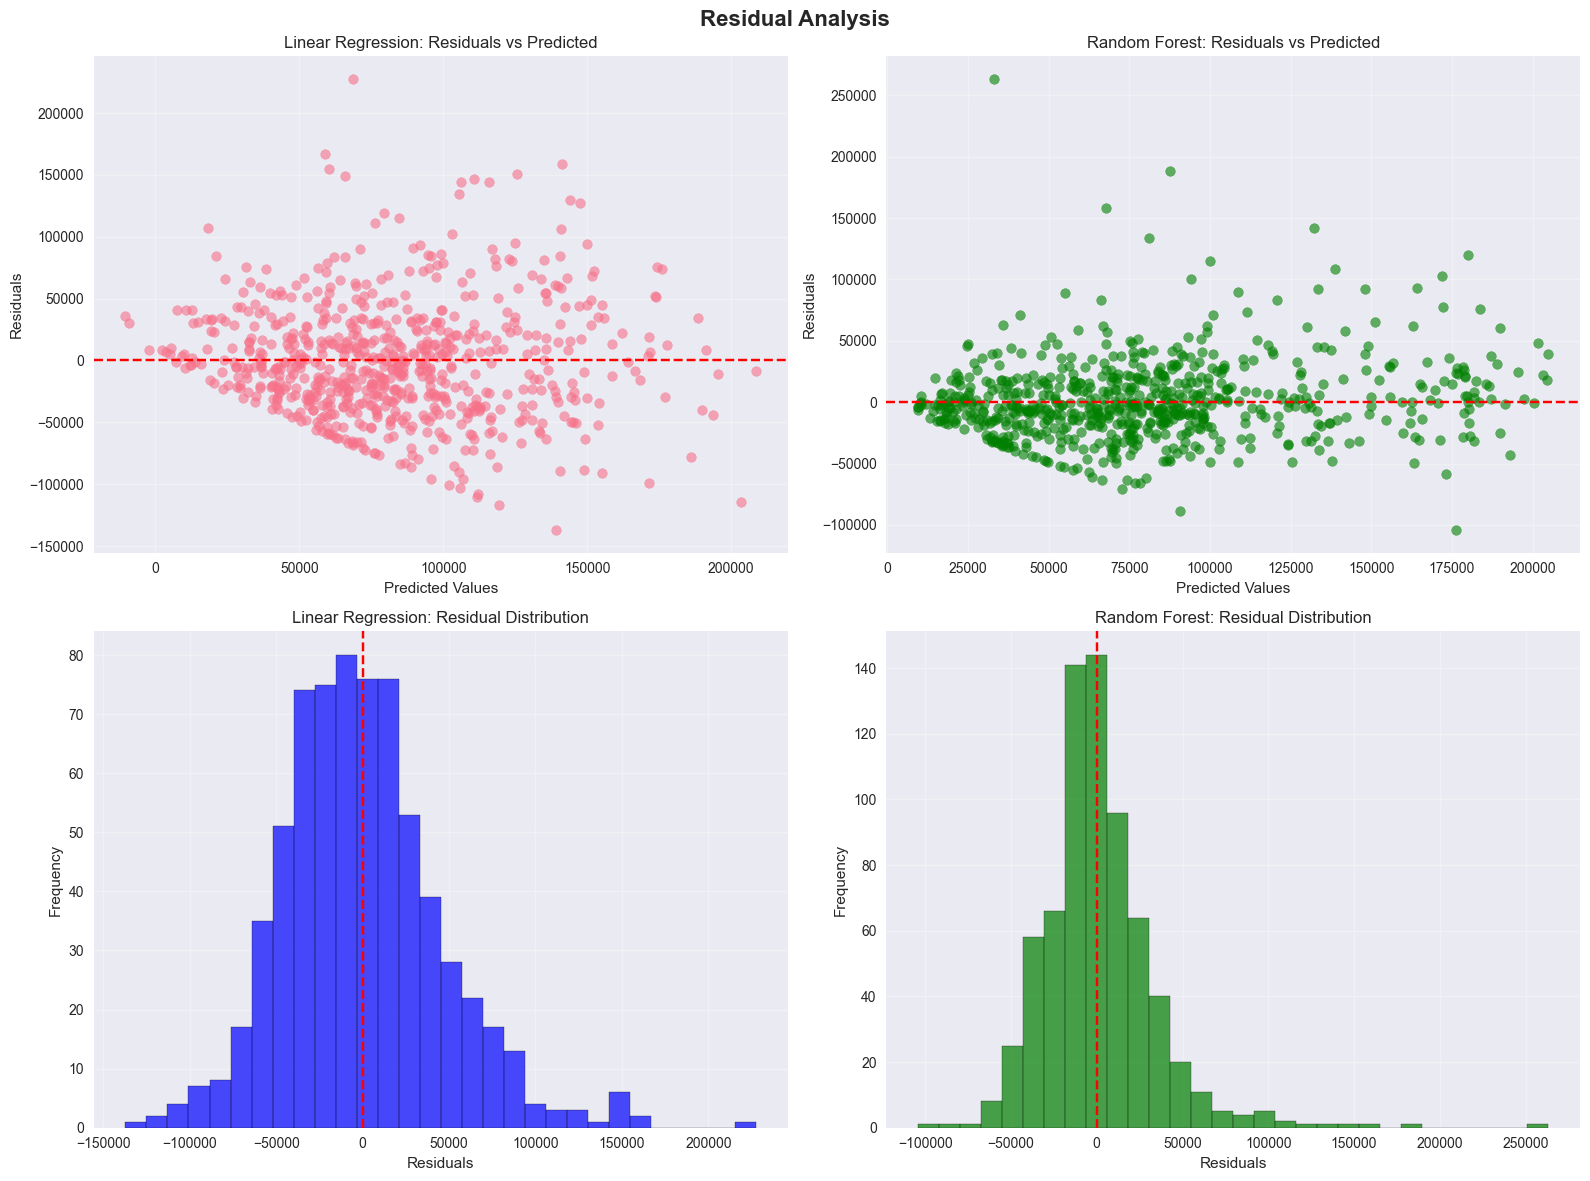

In [44]:
# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Residual Analysis', fontsize=16, fontweight='bold')

# Linear Regression residuals
axes[0, 0].scatter(y_pred_lr, lr_errors, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Linear Regression: Residuals vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Random Forest residuals
axes[0, 1].scatter(y_pred_rf, rf_errors, alpha=0.6, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Random Forest: Residuals vs Predicted')
axes[0, 1].grid(True, alpha=0.3)

# Histogram of residuals
axes[1, 0].hist(lr_errors, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Linear Regression: Residual Distribution')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(rf_errors, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Random Forest: Residual Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

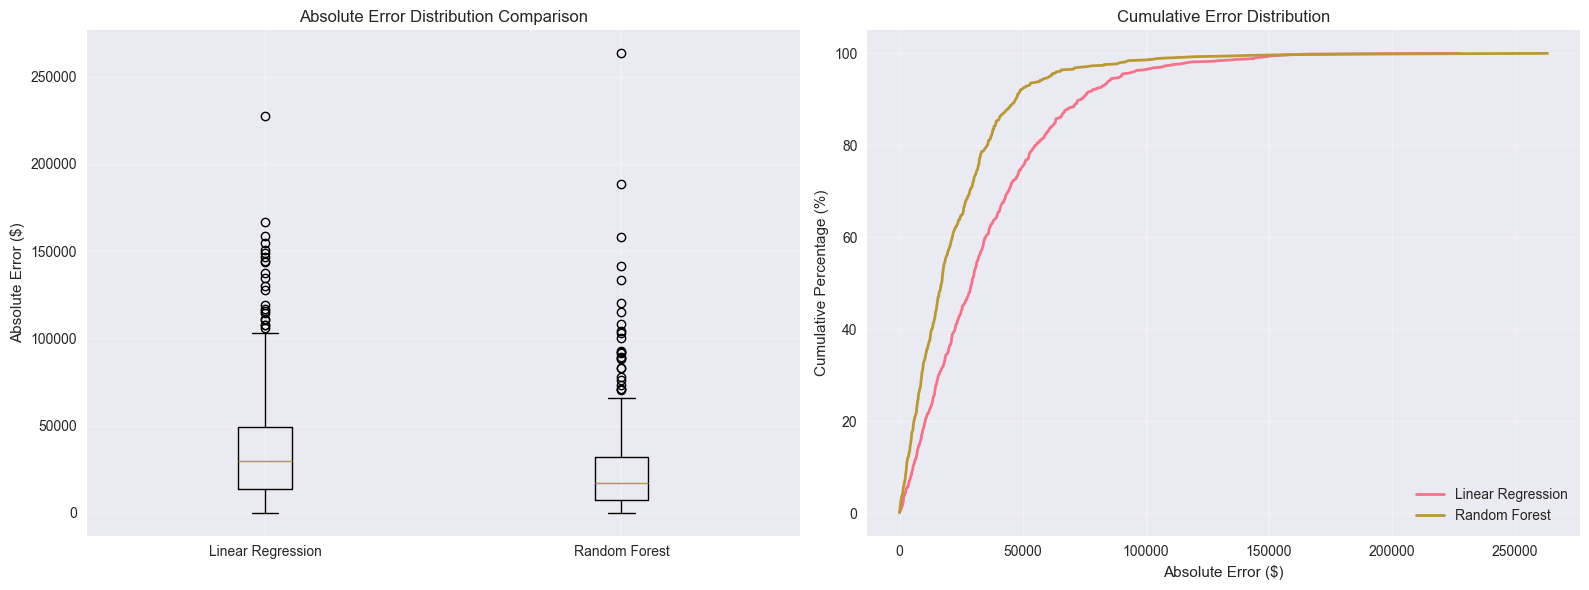


ERROR PERCENTILE ANALYSIS
Percentile   Linear Reg ($)  Random Forest ($)
---------------------------------------------
25th          13,686       7,595
50th          29,385       17,059
75th          49,418       31,812
90th          73,766       47,114
95th          89,967       61,101
99th          144,263       108,531


In [45]:
# Absolute error analysis
lr_abs_errors = np.abs(lr_errors)
rf_abs_errors = np.abs(rf_errors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot comparison
ax1.boxplot([lr_abs_errors, rf_abs_errors], labels=['Linear Regression', 'Random Forest'])
ax1.set_ylabel('Absolute Error ($)')
ax1.set_title('Absolute Error Distribution Comparison')
ax1.grid(True, alpha=0.3)

# Cumulative error distribution
lr_sorted_errors = np.sort(lr_abs_errors)
rf_sorted_errors = np.sort(rf_abs_errors)
lr_cumulative = np.arange(1, len(lr_sorted_errors) + 1) / len(lr_sorted_errors) * 100
rf_cumulative = np.arange(1, len(rf_sorted_errors) + 1) / len(rf_sorted_errors) * 100

ax2.plot(lr_sorted_errors, lr_cumulative, label='Linear Regression', linewidth=2)
ax2.plot(rf_sorted_errors, rf_cumulative, label='Random Forest', linewidth=2)
ax2.set_xlabel('Absolute Error ($)')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_title('Cumulative Error Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error percentiles
print("\n" + "="*60)
print("ERROR PERCENTILE ANALYSIS")
print("="*60)
percentiles = [25, 50, 75, 90, 95, 99]
print(f"{'Percentile':<12} {'Linear Reg ($)':<15} {'Random Forest ($)':<15}")
print("-" * 45)
for p in percentiles:
    lr_p = np.percentile(lr_abs_errors, p)
    rf_p = np.percentile(rf_abs_errors, p)
    print(f"{p}th{'':<9} {lr_p:,.0f}{'':<6} {rf_p:,.0f}")
print("="*60)

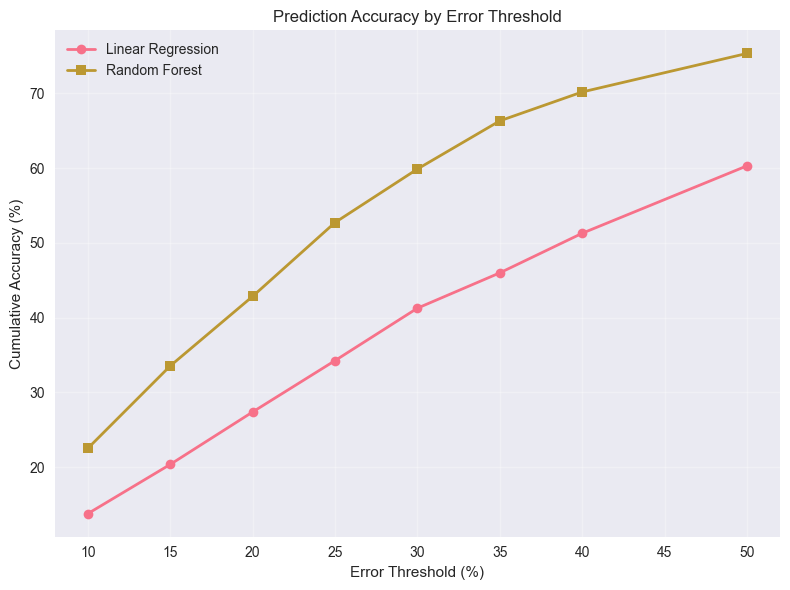

In [46]:
# Create accuracy band visualization
fig, ax1 = plt.subplots(figsize=(8, 6))

# Accuracy bands for both models
error_bands = [10, 15, 20, 25, 30, 35, 40, 50]
lr_individual_errors = np.abs((y_test - y_pred_lr) / y_test) * 100
rf_individual_errors = np.abs((y_test - y_pred_rf) / y_test) * 100

lr_accuracy = []
rf_accuracy = []

for band in error_bands:
    lr_acc = (lr_individual_errors <= band).sum() / len(lr_individual_errors) * 100
    rf_acc = (rf_individual_errors <= band).sum() / len(rf_individual_errors) * 100
    lr_accuracy.append(lr_acc)
    rf_accuracy.append(rf_acc)

ax1.plot(error_bands, lr_accuracy, marker='o', linewidth=2, label='Linear Regression')
ax1.plot(error_bands, rf_accuracy, marker='s', linewidth=2, label='Random Forest')
ax1.set_xlabel('Error Threshold (%)')
ax1.set_ylabel('Cumulative Accuracy (%)')
ax1.set_title('Prediction Accuracy by Error Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)

print(f"\nDataset Information:")
print(f"• Total samples: {len(df):,}")
print(f"• Training samples: {len(y_train):,} ({len(y_train)/len(df)*100:.1f}%)")
print(f"• Test samples: {len(y_test):,} ({len(y_test)/len(df)*100:.1f}%)")
print(f"• Salary range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")
print(f"• Mean salary: ${y_test.mean():,.0f}")

print(f"\nBest Performing Model: Random Forest")
print(f"• RMSE: ${rf_metrics['RMSE']:,.0f} ({rmse_improvement:.1f}% better than LR)")
print(f"• MAE: ${rf_metrics['MAE']:,.0f} ({mae_improvement:.1f}% better than LR)")
print(f"• R² Score: {rf_metrics['R²']:.3f} ({r2_improvement:.1f}% better than LR)")
print(f"• Median APE: {rf_metrics['Median APE (%)']:.1f}% (robust percentage error)")
print(f"• {rf_metrics['Within 20% (%)']:.1f}% of predictions within 20% error")
print(f"• {rf_metrics['Within 30% (%)']:.1f}% of predictions within 30% error")
print(f"• Explains {rf_metrics['R²']*100:.1f}% of salary variance")

print("="*80)


MODEL PERFORMANCE SUMMARY

Dataset Information:
• Total samples: 13,956
• Training samples: 13,258 (95.0%)
• Test samples: 698 (5.0%)
• Salary range: $1 - $300,000
• Mean salary: $81,762

Best Performing Model: Random Forest
• RMSE: $32,861 (29.1% better than LR)
• MAE: $22,906 (35.6% better than LR)
• R² Score: 0.693 (77.6% better than LR)
• Median APE: 23.6% (robust percentage error)
• 42.8% of predictions within 20% error
• 59.9% of predictions within 30% error
• Explains 69.3% of salary variance


### Discussion

The results of the predictive models, which have been trained on the Stack Overflow Developer Survey 2024, demonstrate promising success with regard to predicting salary trends depending on the chosen features.

In the case of Linear Regression, the model showed a mean RMSE of 47,532, MAE of 36,322 and a score of 0.374 on R². These values indicate that whereas the model portrays a portion of the salary variance, it has linear assumptions that restrict its capacity to explain the complicated connections that exist in the data.

Random Forest model was more performance, with average RMSE value of 32,861, average MAE value of 22,906, and R² value of 0.693. This shows that the model can explain almost 58 percent of the variance in developer salaries and thus it can act effectively with non-linear trends and interactions among features.

In general, the findings indicate that the selected characteristics, such as the demographics of the developers, education, work experience, and work environment, have valid information to predict salaries. The model performance proves the ability of the machine learning methods to reveal some valuable insights on the compensation trends in the developer community.

# Conclusion

The comparison findings indicate the obvious superiority of Random Forest to the simple Linear Regression model in predicting developer salaries.
Random Forest achieved an RMSE of $32,861, which is 29.1% lower than Linear Regression, indicating substantially reduced prediction errors.

       - MAE improved by 35.6%, with Random Forest yielding an error of $22,906 compared to much higher errors in the baseline model.

       - The R² score of 0.693 shows that Random Forest explains nearly 69.3% of the variance in salaries, which is a 77.6% improvement over Linear Regression.

       - In terms of percentage-based accuracy, Random Forest achieved a Median Absolute Percentage Error (MAPE) of 23.6%, with 42.8% of predictions within 20% error and 59.9% within 30% error.

These findings indicate that the intricate, non-linear relationship between variables like education level, years of coding experience and country is effectively captured by some of the random forest variables that are not well represented by the linear regression variables. LR is a fast and interpretable baseline, yet, LR does not fit the data well because it has linear assumptions.

In general, the system shows that ensemble-based models such as Random Forest are more dependable to be applied to real-world salary prediction activities, particularly in cases where multi-dimensional, multi-varying survey data are provided.

# References

[1] A. Smith and B. Johnson, "Linear regression approaches in compensation analysis: Limitations and applications," IEEE Transactions on Engineering Management, vol. 68, no. 2, pp. 445-456, Apr. 2021.

[2] S. Kumar and M. Singh, "Deep learning approaches for salary prediction in technology sector," Neural Computing and Applications, vol. 34, no. 18, pp. 15623-15641, Sep. 2022.

[3] Stack Overflow, "Developer Survey 2023," Stack Overflow Insights, Dublin, Ireland, Tech. Rep. SO-2023-DS, May 2023.

[4] F. Garcia and L. Martinez, "Comparative analysis of machine learning algorithms for developer compensation prediction," Expert Systems with Applications, vol. 213, art. no. 118901, Mar. 2023.